##**Deep Learning for Predicting Airline Stock Responses to Oil Price Shocks: A Multi-Factor LSTM-Attention and Transformer Approach with Geopolitical Risk Evidence**

**Installing Libraries**

In [ ]:
# Install required libraries not available by default in Colab
!pip install pandas-datareader pytorch-forecasting pytorch-lightning shap -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.0 MB/s eta 0:00:00


**Import All Packages**

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas_datareader as pdr

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error, r2_score)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import shap

print("All packages imported")
print(f"PyTorch version: {torch.__version__}")

All packages imported
PyTorch version: 2.11.0+cpu


**Downloading daily Oil Price Data**

In [ ]:
START = '2007-01-01'
END   = '2026-06-08'

# Brent crude
brent = yf.download('BZ=F', start=START, end=END, progress=False)
brent = brent[['Close']].copy()
brent.columns = ['Brent_Price_USD']
brent.index = pd.to_datetime(brent.index)
brent = brent[~brent.index.duplicated()]

# WTI crude
wti = yf.download('CL=F', start=START, end=END, progress=False)
wti = wti[['Close']].copy()
wti.columns = ['WTI_Price_USD']
wti.index = pd.to_datetime(wti.index)
wti = wti[~wti.index.duplicated()]

print(f"Brent: {len(brent)} daily rows | "
      f"{brent.index.min().date()} to {brent.index.max().date()}")
print(f"WTI:   {len(wti)} daily rows | "
      f"{wti.index.min().date()} to {wti.index.max().date()}")
print(f"Missing Brent: {brent.isnull().sum().values[0]}")
print(f"Missing WTI:   {wti.isnull().sum().values[0]}")

Brent: 4692 daily rows | 2007-07-30 to 2026-06-05
WTI:   4888 daily rows | 2007-01-02 to 2026-06-05
Missing Brent: 0
Missing WTI:   0


**Downloading Airline Stocks Daily (2007–2026)**

In [ ]:
tickers = {
    'AAL': 'American',
    'DAL': 'Delta',
    'UAL': 'United',
    'LUV': 'Southwest'
}

frames = []
for ticker, name in tickers.items():
    tmp = yf.download(ticker, start=START, end=END, progress=False)
    tmp = tmp[['Close', 'Volume']].copy()
    tmp.columns = [f'{name}_Stock', f'{name}_Volume']
    tmp.index = pd.to_datetime(tmp.index)
    tmp = tmp[~tmp.index.duplicated()]
    frames.append(tmp)

airline_df = pd.concat(frames, axis=1)
airline_df.index.name = 'Date'

airline_df['Avg_Airline_Stock'] = airline_df[[
    'American_Stock', 'Delta_Stock',
    'United_Stock',   'Southwest_Stock']].mean(axis=1)

print(f"Airline data: {len(airline_df)} daily rows")
print(f"Period: {airline_df.index.min().date()} "
      f"to {airline_df.index.max().date()}")
print(f"Missing values:\n{airline_df.isnull().sum()}")

Airline data: 4887 daily rows
Period: 2007-01-03 to 2026-06-05
Missing values:
American_Stock        0
American_Volume       0
Delta_Stock          83
Delta_Volume         83
United_Stock          0
United_Volume         0
Southwest_Stock       0
Southwest_Volume      0
Avg_Airline_Stock     0
dtype: int64


**Downloading Extra macroeconomic features**

In [ ]:
# Extra macroeconomic features
# VIX, S&P500, Dollar Index, JETS ETF via Yahoo Finance
# Interest rates via FRED

START = '2007-01-01'
END   = '2026-06-08'

# VIX — market fear index
vix = yf.download('^VIX', start=START,
                   end=END, progress=False)
vix = vix[['Close']].copy()
vix.columns = ['VIX']
vix.index = pd.to_datetime(vix.index)

# S&P 500 — overall market sentiment
sp500 = yf.download('^GSPC', start=START,
                     end=END, progress=False)
sp500 = sp500[['Close']].copy()
sp500.columns = ['SP500']
sp500.index = pd.to_datetime(sp500.index)

# JETS ETF — airline sector index
jets = yf.download('JETS', start='2015-04-01',
                    end=END, progress=False)
jets = jets[['Close']].copy()
jets.columns = ['JETS_ETF']
jets.index = pd.to_datetime(jets.index)

# USD Dollar Index
dxy = yf.download('DX-Y.NYB', start=START,
                   end=END, progress=False)
dxy = dxy[['Close']].copy()
dxy.columns = ['USD_Index']
dxy.index = pd.to_datetime(dxy.index)

print(f"VIX:     {len(vix)} rows, "
      f"{vix.index.min().date()} to "
      f"{vix.index.max().date()}")
print(f"SP500:   {len(sp500)} rows, "
      f"{sp500.index.min().date()} to "
      f"{sp500.index.max().date()}")
print(f"JETS:    {len(jets)} rows, "
      f"{jets.index.min().date()} to "
      f"{jets.index.max().date()}")
print(f"USD Idx: {len(dxy)} rows, "
      f"{dxy.index.min().date()} to "
      f"{dxy.index.max().date()}")

VIX:     4888 rows, 2007-01-03 to 2026-06-05
SP500:   4887 rows, 2007-01-03 to 2026-06-05
JETS:    2792 rows, 2015-04-30 to 2026-06-05
USD Idx: 4889 rows, 2007-01-02 to 2026-06-05


**Download Interest Rate via FRED**

In [ ]:
# Fed Funds Rate via FRED
import pandas_datareader as pdr

try:
    fed_rate = pdr.get_data_fred('FEDFUNDS',
                                  start=START,
                                  end=END)
    fed_rate.columns = ['Fed_Rate']
    fed_rate.index = pd.to_datetime(fed_rate.index)
    fed_rate = fed_rate.resample('B').ffill()
    print(f"Fed Rate: {len(fed_rate)} rows, "
          f"{fed_rate.index.min().date()} to "
          f"{fed_rate.index.max().date()}")
except:
    print("FRED timed out — creating Fed Rate from Yahoo")
    fed_rate = yf.download('^IRX', start=START,
                            end=END, progress=False)
    fed_rate = fed_rate[['Close']].copy()
    fed_rate.columns = ['Fed_Rate']
    fed_rate.index = pd.to_datetime(fed_rate.index)
    print(f"Fed Rate (proxy): {len(fed_rate)} rows")

Fed Rate: 5045 rows, 2007-01-01 to 2026-05-01


**Merging everything**

In [ ]:
# Merge all datasets on Date index
df = brent.copy()
df = df.join(wti, how='inner')
df = df.join(airline_df, how='inner')
df = df.join(vix, how='left')
df = df.join(sp500, how='left')
df = df.join(jets, how='left')
df = df.join(dxy, how='left')
df = df.join(fed_rate, how='left')

# Forward fill Fed Rate (monthly → daily)
df['Fed_Rate'] = df['Fed_Rate'].ffill()

# Add time features
df['Year']  = df.index.year
df['Month'] = df.index.month
df['Week']  = df.index.isocalendar().week.astype(int)
df['DOW']   = df.index.dayofweek

# COVID flag
covid = ((df.index >= '2020-03-01') &
         (df.index <= '2021-06-01'))
df['COVID_Flag'] = covid.astype(int)

# Geopolitical shock flag
geo = (((df.index >= '2022-02-24') &
         (df.index <= '2022-12-31')) |
        (df.index >= '2026-04-01'))
df['Geo_Shock_Flag'] = geo.astype(int)

# Drop NaN
df = df.dropna()

print(f"Final shape: {df.shape}")
print(f"Period: {df.index.min().date()} "
      f"to {df.index.max().date()}")
print(f"Total rows: {len(df)}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Final shape: (2790, 22)
Period: 2015-04-30 to 2026-06-05
Total rows: 2790
Missing values: 0


,Brent_Price_USD,WTI_Price_USD,American_Stock,American_Volume,Delta_Stock,Delta_Volume,United_Stock,United_Volume,Southwest_Stock,Southwest_Volume,...,SP500,JETS_ETF,USD_Index,Fed_Rate,Year,Month,Week,DOW,COVID_Flag,Geo_Shock_Flag
Date,,,,,,,,,,,,,,,,,,,,,
2015-04-30,66.779999,59.630001,45.941624,9400400,38.958763,9256600.0,59.740002,7179900,35.713337,6492100,...,2085.510010,22.858271,94.599998,0.12,2015,4,18,3,0,0
2015-05-01,66.459999,59.150002,46.988132,8084600,39.848946,11469900.0,61.400002,4519800,37.509575,7753100,...,2108.290039,23.502777,95.300003,0.12,2015,5,18,4,0,0
2015-05-04,66.449997,58.930000,46.569534,5589800,39.526035,9653100.0,60.919998,3769700,36.831585,5539200,...,2114.489990,23.304323,95.480003,0.12,2015,5,19,0,0,0
2015-05-05,67.519997,60.400002,44.723873,11385000,38.312935,11350400.0,59.230000,3617200,35.686916,6285900,...,2089.459961,22.680607,95.129997,0.12,2015,5,19,1,0,0
2015-05-06,67.769997,60.930000,44.761936,10116400,38.531559,12783300.0,59.439999,4303600,35.995102,6719600,...,2080.149902,22.661707,94.129997,0.12,2015,5,19,2,0,0


**Sanity check plot**

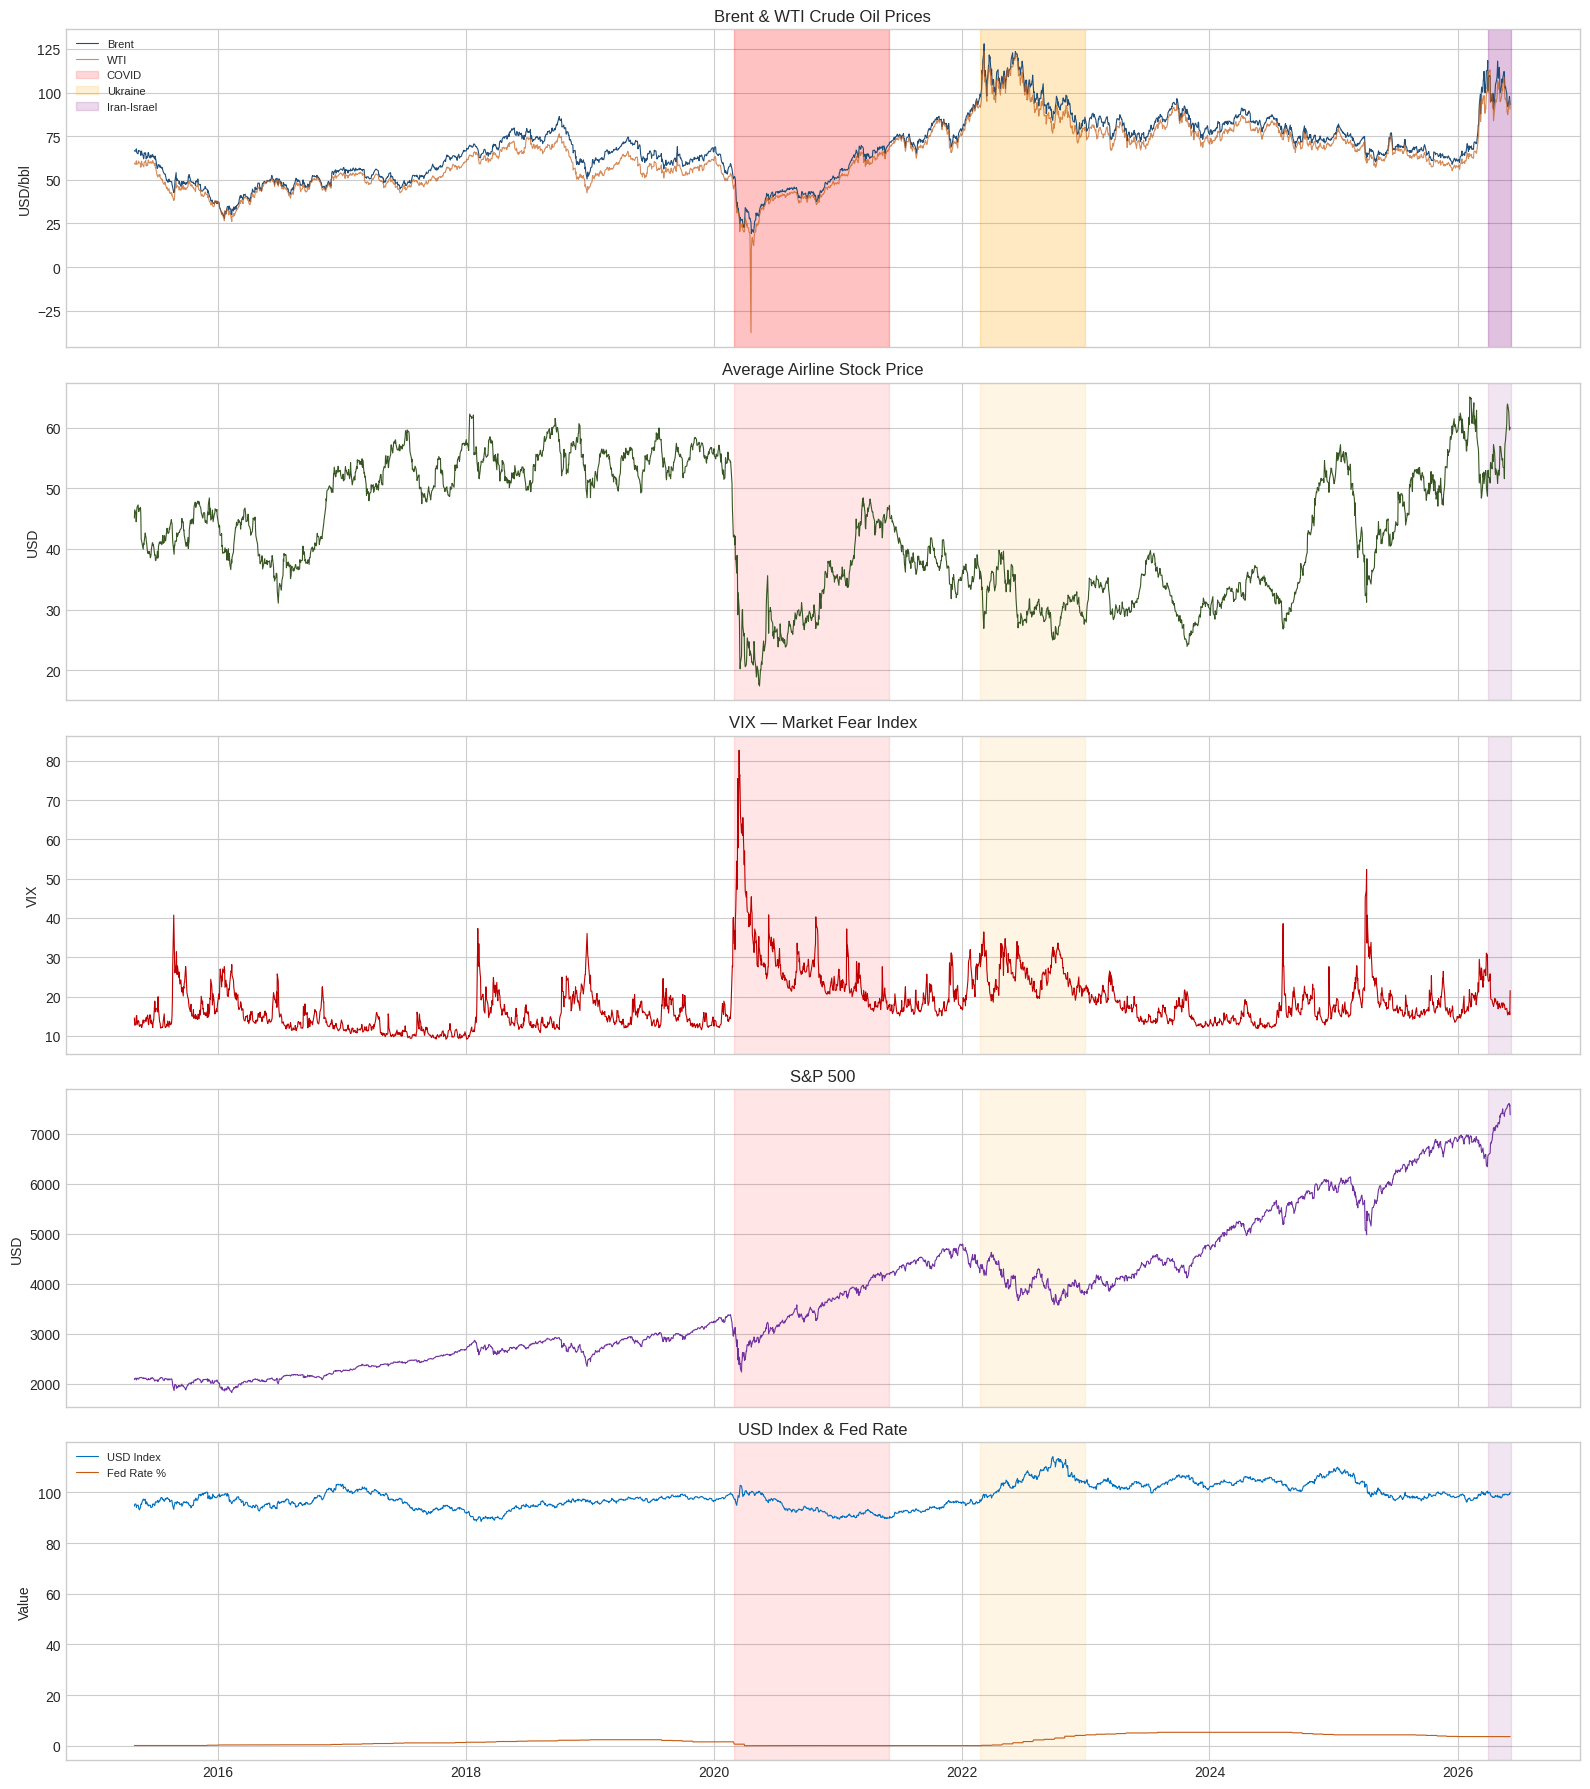

Sanity check complete


In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True)

axes[0].plot(df.index, df['Brent_Price_USD'],
             color='#1f4e79', linewidth=0.8, label='Brent')
axes[0].plot(df.index, df['WTI_Price_USD'],
             color='#c55a11', linewidth=0.8,
             alpha=0.7, label='WTI')
axes[0].axvspan(pd.Timestamp('2020-03-01'),
                pd.Timestamp('2021-06-01'),
                alpha=0.15, color='red', label='COVID')
axes[0].axvspan(pd.Timestamp('2022-02-24'),
                pd.Timestamp('2022-12-31'),
                alpha=0.15, color='orange', label='Ukraine')
axes[0].axvspan(pd.Timestamp('2026-04-01'),
                pd.Timestamp('2026-06-08'),
                alpha=0.15, color='purple', label='Iran-Israel')
axes[0].set_ylabel('USD/bbl')
axes[0].set_title('Brent & WTI Crude Oil Prices')
axes[0].legend(fontsize=8)

axes[1].plot(df.index, df['Avg_Airline_Stock'],
             color='#375623', linewidth=0.8)
axes[1].set_ylabel('USD')
axes[1].set_title('Average Airline Stock Price')

axes[2].plot(df.index, df['VIX'],
             color='#c00000', linewidth=0.8)
axes[2].set_ylabel('VIX')
axes[2].set_title('VIX — Market Fear Index')

axes[3].plot(df.index, df['SP500'],
             color='#7030a0', linewidth=0.8)
axes[3].set_ylabel('USD')
axes[3].set_title('S&P 500')

axes[4].plot(df.index, df['USD_Index'],
             color='#0070c0', linewidth=0.8,
             label='USD Index')
axes[4].plot(df.index, df['Fed_Rate'],
             color='#c55a11', linewidth=0.8,
             label='Fed Rate %')
axes[4].set_ylabel('Value')
axes[4].set_title('USD Index & Fed Rate')
axes[4].legend(fontsize=8)

for ax in axes:
    ax.axvspan(pd.Timestamp('2020-03-01'),
               pd.Timestamp('2021-06-01'),
               alpha=0.1, color='red')
    ax.axvspan(pd.Timestamp('2022-02-24'),
               pd.Timestamp('2022-12-31'),
               alpha=0.1, color='orange')
    ax.axvspan(pd.Timestamp('2026-04-01'),
               pd.Timestamp('2026-06-08'),
               alpha=0.1, color='purple')

plt.tight_layout()
plt.savefig('sanity_check_v2.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Sanity check complete")

**Check Basic statistics Before Cleaning**

In [ ]:
# Basic statistics to understand distributions before cleaning
print("Basic Statistics:")
print(df.describe().round(2))

Basic Statistics:
       Brent_Price_USD  WTI_Price_USD  American_Stock  American_Volume  \
count          2790.00        2790.00         2790.00     2.790000e+03   
mean             67.72          63.41           25.19     2.942584e+07   
std              18.33          17.93           13.03     2.975287e+07   
min              19.33         -37.63            9.04     1.352400e+06   
25%              54.34          50.35           13.80     7.410900e+06   
50%              67.11          62.48           19.44     2.209545e+07   
75%              79.08          74.20           37.33     4.132655e+07   
max             127.98         123.70           56.99     4.286171e+08   

       Delta_Stock  Delta_Volume  United_Stock  United_Volume  \
count      2790.00  2.790000e+03       2790.00   2.790000e+03   
mean         44.39  1.141132e+07         62.60   9.333888e+06   
std          10.32  1.024673e+07         21.21   1.162458e+07   
min          18.57  1.076000e+06         19.92   7.7110

**Check for Outliers Using IQR Method**

In [ ]:
cap_cols = ['Brent_Price_USD', 'WTI_Price_USD',
            'Avg_Airline_Stock', 'VIX',
            'SP500', 'USD_Index', 'Fed_Rate',
            'JETS_ETF']

print("Outlier Detection Using IQR Method:")
print("-" * 50)
for col in cap_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}:")
    print(f"   Q1={Q1:.2f} | Q3={Q3:.2f} | IQR={IQR:.2f}")
    print(f"   Lower={lower:.2f} | Upper={upper:.2f}")
    print(f"   Outliers: {len(outliers)} rows "
          f"({len(outliers)/len(df)*100:.1f}%)")
    print()

Outlier Detection Using IQR Method:
--------------------------------------------------
Brent_Price_USD:
   Q1=54.34 | Q3=79.08 | IQR=24.75
   Lower=17.21 | Upper=116.21
   Outliers: 25 rows (0.9%)

WTI_Price_USD:
   Q1=50.35 | Q3=74.20 | IQR=23.85
   Lower=14.57 | Upper=109.98
   Outliers: 41 rows (1.5%)

Avg_Airline_Stock:
   Q1=34.18 | Q3=52.68 | IQR=18.50
   Lower=6.42 | Upper=80.44
   Outliers: 0 rows (0.0%)

VIX:
   Q1=13.63 | Q3=21.38 | IQR=7.75
   Lower=2.01 | Upper=33.00
   Outliers: 88 rows (3.2%)

SP500:
   Q1=2629.35 | Q3=4558.66 | IQR=1929.31
   Lower=-264.63 | Upper=7452.63
   Outliers: 10 rows (0.4%)

USD_Index:
   Q1=95.00 | Q3=101.78 | IQR=6.78
   Lower=84.83 | Upper=111.95
   Outliers: 20 rows (0.7%)

Fed_Rate:
   Q1=0.34 | Q3=4.10 | IQR=3.76
   Lower=-5.30 | Upper=9.74
   Outliers: 0 rows (0.0%)

JETS_ETF:
   Q1=19.97 | Q3=27.88 | IQR=7.91
   Lower=8.09 | Upper=39.75
   Outliers: 0 rows (0.0%)



**Visualise Outliers with Boxplots**

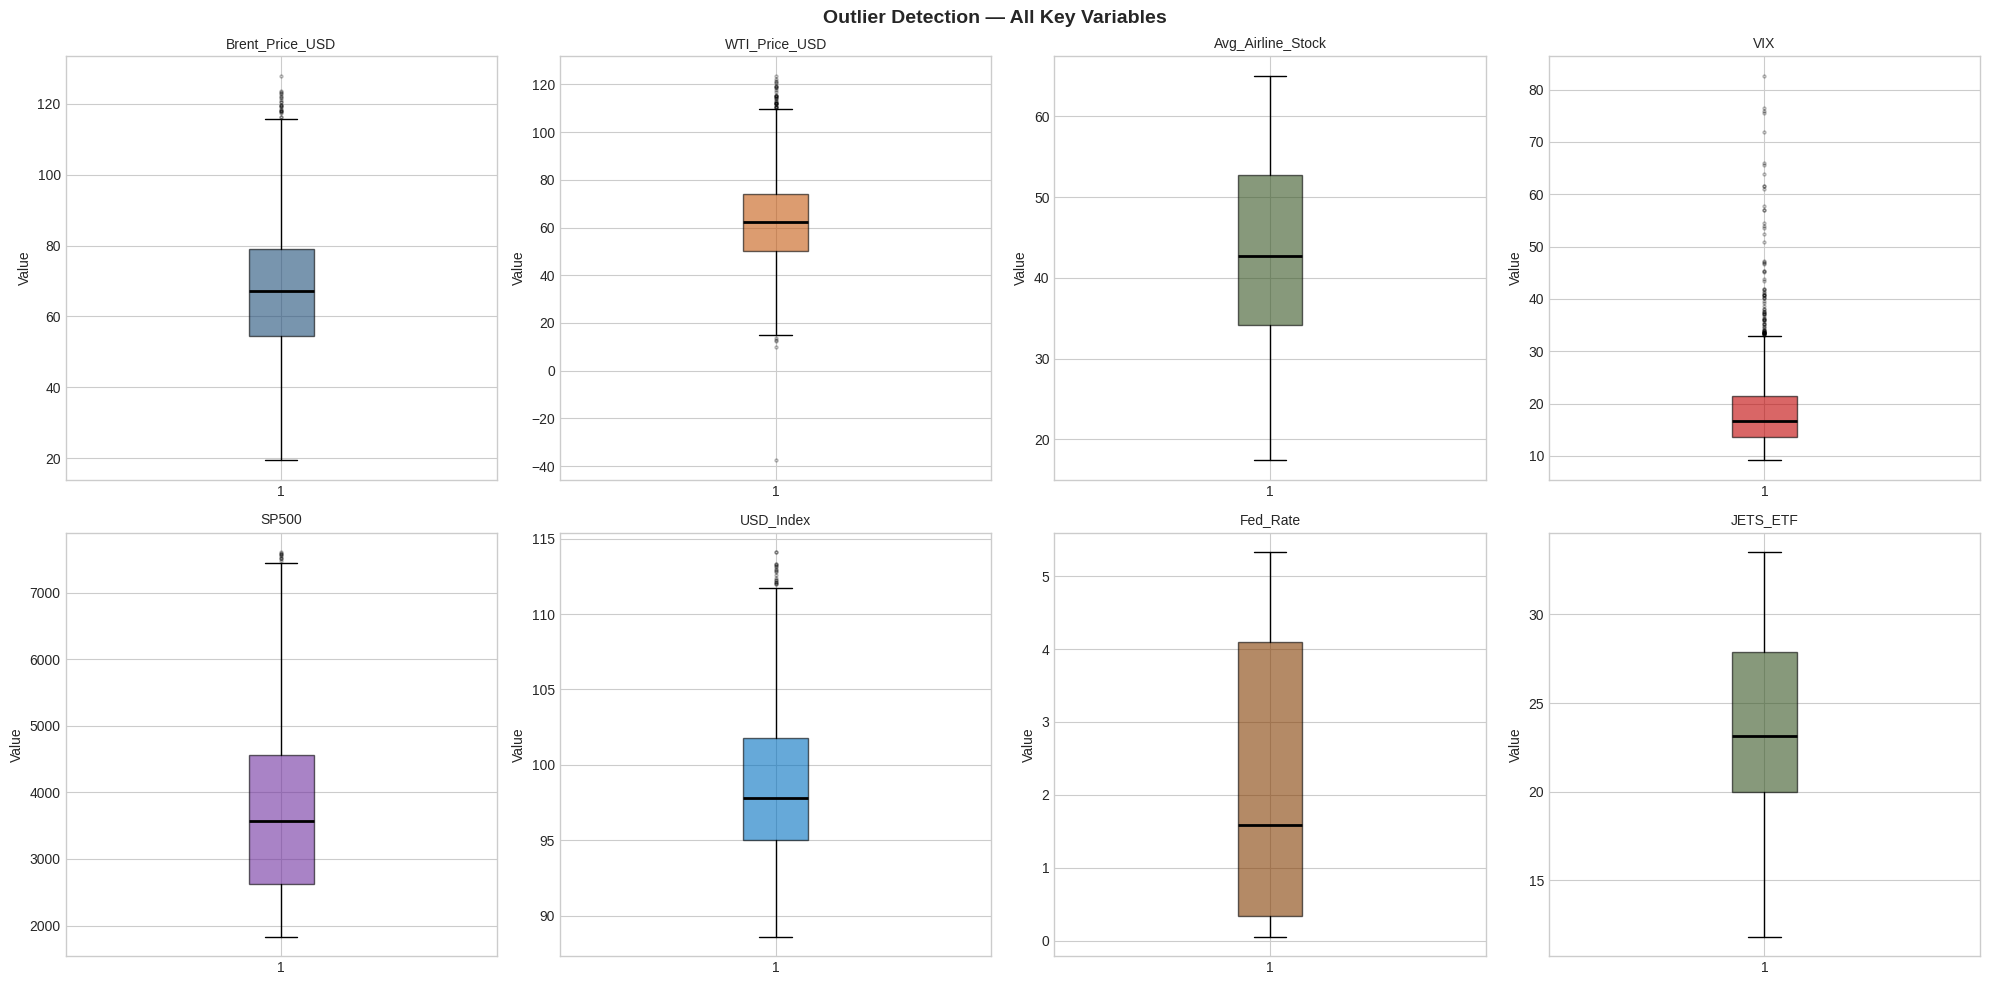

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

colors = ['#1f4e79', '#c55a11', '#375623',
          '#c00000', '#7030a0', '#0070c0',
          '#833c00', '#375623']

for i, (col, color) in enumerate(zip(cap_cols, colors)):
    row, c = divmod(i, 4)
    axes[row][c].boxplot(
        df[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.6),
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markersize=2,
                        alpha=0.3, color=color))
    axes[row][c].set_title(col, fontsize=10)
    axes[row][c].set_ylabel('Value')

plt.suptitle('Outlier Detection — All Key Variables',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outliers_boxplot.png',
            dpi=150, bbox_inches='tight')
plt.show()

**Handle Outliers (Cap not Drop)**

In [ ]:
df_clean = df.copy()

print("Capping outliers using IQR Winsorization:")
print("-" * 50)

for col in cap_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(df_clean[
        (df_clean[col] < lower) |
        (df_clean[col] > upper)])
    df_clean[col] = df_clean[col].clip(lower, upper)
    print(f"{col}: {before} outliers capped")

print(f"\nDataset shape unchanged: {df_clean.shape}")
print(f"Missing values after capping: "
      f"{df_clean.isnull().sum().sum()}")
df_clean.describe().round(2)

Capping outliers using IQR Winsorization:
--------------------------------------------------
Brent_Price_USD: 25 outliers capped
WTI_Price_USD: 41 outliers capped
Avg_Airline_Stock: 0 outliers capped
VIX: 88 outliers capped
SP500: 10 outliers capped
USD_Index: 20 outliers capped
Fed_Rate: 0 outliers capped
JETS_ETF: 0 outliers capped

Dataset shape unchanged: (2790, 22)
Missing values after capping: 0


,Brent_Price_USD,WTI_Price_USD,American_Stock,American_Volume,Delta_Stock,Delta_Volume,United_Stock,United_Volume,Southwest_Stock,Southwest_Volume,...,SP500,JETS_ETF,USD_Index,Fed_Rate,Year,Month,Week,DOW,COVID_Flag,Geo_Shock_Flag
count,2790.00,2790.00,2790.00,2.790000e+03,2790.00,2.790000e+03,2790.00,2.790000e+03,2790.00,2.790000e+03,...,2790.00,2790.00,2790.00,2790.00,2790.00,2790.00,2790.00,2790.00,2790.00,2790.00
mean,67.68,63.37,25.19,2.942584e+07,44.39,1.141132e+07,62.60,9.333888e+06,39.78,7.668952e+06,...,3789.67,23.60,98.39,2.12,2020.37,6.53,26.59,2.02,0.11,0.09
std,18.23,17.65,13.03,2.975287e+07,10.32,1.024673e+07,21.21,1.162458e+07,9.28,5.364301e+06,...,1443.09,4.72,4.79,1.90,3.23,3.41,14.90,1.40,0.32,0.29
min,19.33,14.57,9.04,1.352400e+06,18.57,1.076000e+06,19.92,7.711000e+05,21.04,1.098400e+06,...,1829.08,11.82,88.59,0.05,2015.00,1.00,1.00,0.00,0.00,0.00
25%,54.34,50.35,13.80,7.410900e+06,37.55,6.742200e+06,45.19,3.821075e+06,31.90,4.750800e+06,...,2629.35,19.97,95.00,0.34,2018.00,4.00,14.00,1.00,0.00,0.00
50%,67.11,62.48,19.44,2.209545e+07,43.45,8.921800e+06,56.95,5.974300e+06,38.75,6.492650e+06,...,3570.22,23.13,97.77,1.58,2020.00,7.00,26.00,2.00,0.00,0.00
75%,79.08,74.20,37.33,4.132655e+07,50.41,1.223970e+07,80.23,1.005835e+07,47.86,8.877000e+06,...,4558.66,27.88,101.78,4.10,2023.00,9.00,39.75,3.00,0.00,0.00
max,116.21,109.98,56.99,4.286171e+08,82.49,1.346265e+08,117.53,1.428128e+08,59.70,1.010078e+08,...,7452.63,33.51,111.95,5.33,2026.00,12.00,53.00,4.00,1.00,1.00


**Feature Engineering (Lag Features + Shock Indicators)**

In [ ]:
# Minimal but meaningful feature engineering

# LAG FEATURES
# Based on cross-correlation peak at 60 days
# 5, 21, 63 trading days = 1 week, 1 month, 3 months
df_clean['Brent_lag5']  = df_clean['Brent_Price_USD'].shift(5)
df_clean['Brent_lag21'] = df_clean['Brent_Price_USD'].shift(21)
df_clean['Brent_lag63'] = df_clean['Brent_Price_USD'].shift(63)

# PRICE DYNAMICS
# Rate of change — how fast oil is moving
df_clean['Brent_pct_change'] = \
    df_clean['Brent_Price_USD'].pct_change() * 100

# 21-day volatility — sustained uncertainty
df_clean['Brent_volatility_21'] = \
    df_clean['Brent_Price_USD'].rolling(21).std()

# MARKET STRUCTURE
# Brent-WTI spread — Middle East supply premium
df_clean['Brent_WTI_Spread'] = (
    df_clean['Brent_Price_USD'] -
    df_clean['WTI_Price_USD'])

# Shock flag — extreme daily oil move >3%
df_clean['Oil_Shock_Flag'] = (
    df_clean['Brent_pct_change'].abs() > 3).astype(int)

# TARGET VARIABLE
# 21-day rolling % change in airline stock
df_clean['Target'] = \
    df_clean['Avg_Airline_Stock']\
    .rolling(21).mean()\
    .pct_change(21) * 100

# Drop NaN from lag and rolling operations
df_clean = df_clean.dropna()

print(f"Shape after feature engineering: {df_clean.shape}")
print(f"Period: {df_clean.index.min().date()} "
      f"to {df_clean.index.max().date()}")
print(f"Total rows: {len(df_clean)}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print(f"\nNew features added:")
new_feats = ['Brent_lag5', 'Brent_lag21', 'Brent_lag63',
             'Brent_pct_change', 'Brent_volatility_21',
             'Brent_WTI_Spread', 'Oil_Shock_Flag', 'Target']
for f in new_feats:
    print(f"   {f}")

Shape after feature engineering: (2727, 30)
Period: 2015-07-30 to 2026-06-05
Total rows: 2727
Missing values: 0

New features added:
   Brent_lag5
   Brent_lag21
   Brent_lag63
   Brent_pct_change
   Brent_volatility_21
   Brent_WTI_Spread
   Oil_Shock_Flag
   Target


**Drop NaN from Lag Features & Final Clean Check**

In [ ]:
# Lag features create NaN at the start — drop them
df_clean = df_clean.dropna()

print(f"Final clean dataset shape: {df_clean.shape}")
print(f"Period: {df_clean.index.min().date()} "
      f"to {df_clean.index.max().date()}")
print(f"Total rows: {len(df_clean)}")
print(f"Total columns: {len(df_clean.columns)}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print(f"\nAll columns:")
for col in df_clean.columns:
    print(f"   {col}")

Final clean dataset shape: (2727, 30)
Period: 2015-07-30 to 2026-06-05
Total rows: 2727
Total columns: 30
Missing values: 0

All columns:
   Brent_Price_USD
   WTI_Price_USD
   American_Stock
   American_Volume
   Delta_Stock
   Delta_Volume
   United_Stock
   United_Volume
   Southwest_Stock
   Southwest_Volume
   Avg_Airline_Stock
   VIX
   SP500
   JETS_ETF
   USD_Index
   Fed_Rate
   Year
   Month
   Week
   DOW
   COVID_Flag
   Geo_Shock_Flag
   Brent_lag5
   Brent_lag21
   Brent_lag63
   Brent_pct_change
   Brent_volatility_21
   Brent_WTI_Spread
   Oil_Shock_Flag
   Target


**Save Clean Dataset**

In [ ]:
# Save to Google Drive so we never lose it
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

save_path = '/content/drive/MyDrive/EM10DS/'
import os
os.makedirs(save_path, exist_ok=True)

df_clean.to_csv(save_path + 'dataset_clean.csv')
print(f"Dataset saved to Google Drive")
print(f"Shape: {df_clean.shape}")
print(f"File: {save_path}dataset_clean.csv")

Mounted at /content/drive
Dataset saved to Google Drive
Shape: (2727, 30)
File: /content/drive/MyDrive/EM10DS/dataset_clean.csv


**Distribution of All Key Variables**

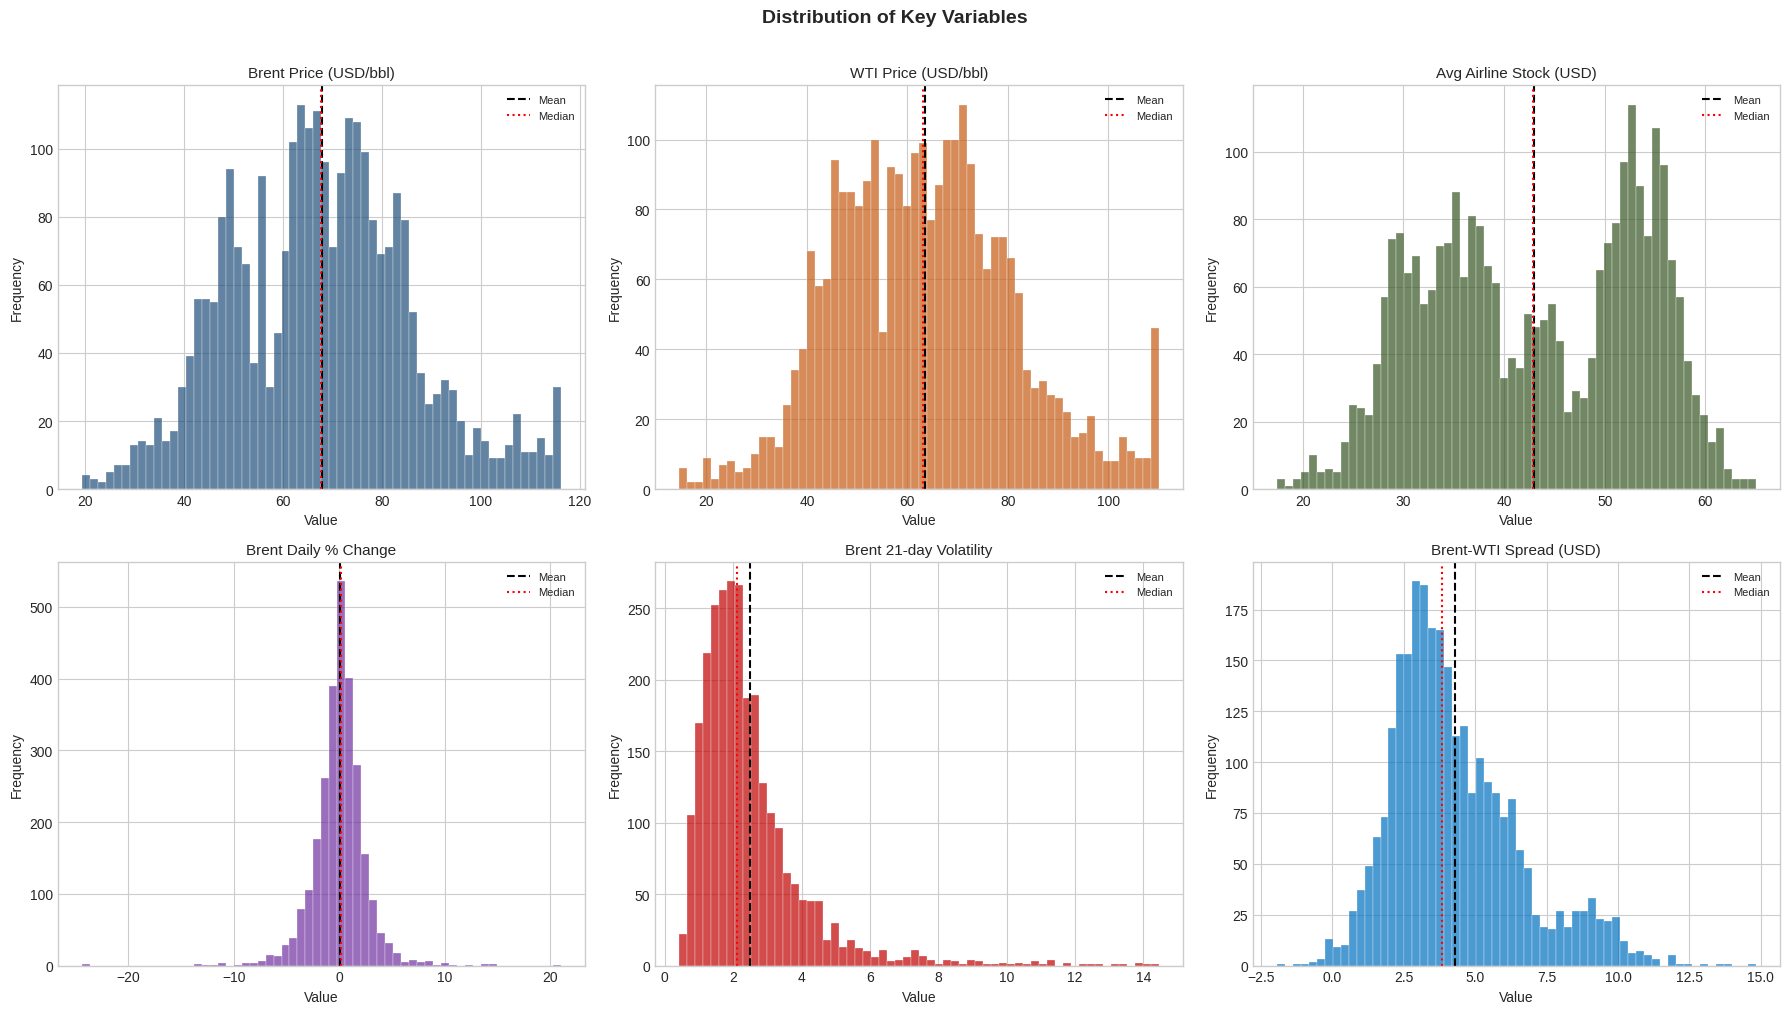

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cols = ['Brent_Price_USD', 'WTI_Price_USD',
        'Avg_Airline_Stock', 'Brent_pct_change',
        'Brent_volatility_21', 'Brent_WTI_Spread']

titles = ['Brent Price (USD/bbl)',
          'WTI Price (USD/bbl)',
          'Avg Airline Stock (USD)',
          'Brent Daily % Change',
          'Brent 21-day Volatility',
          'Brent-WTI Spread (USD)']

colors = ['#1f4e79','#c55a11','#375623',
          '#7030a0','#c00000','#0070c0']

for i, (col, title, color) in enumerate(
        zip(cols, titles, colors)):
    row, c = divmod(i, 3)
    axes[row][c].hist(df_clean[col], bins=60,
                      color=color, alpha=0.7,
                      edgecolor='white', linewidth=0.3)
    axes[row][c].axvline(df_clean[col].mean(),
                          color='black', linewidth=1.5,
                          linestyle='--', label='Mean')
    axes[row][c].axvline(df_clean[col].median(),
                          color='red', linewidth=1.5,
                          linestyle=':', label='Median')
    axes[row][c].set_title(title, fontsize=11)
    axes[row][c].set_xlabel('Value')
    axes[row][c].set_ylabel('Frequency')
    axes[row][c].legend(fontsize=8)

plt.suptitle('Distribution of Key Variables',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

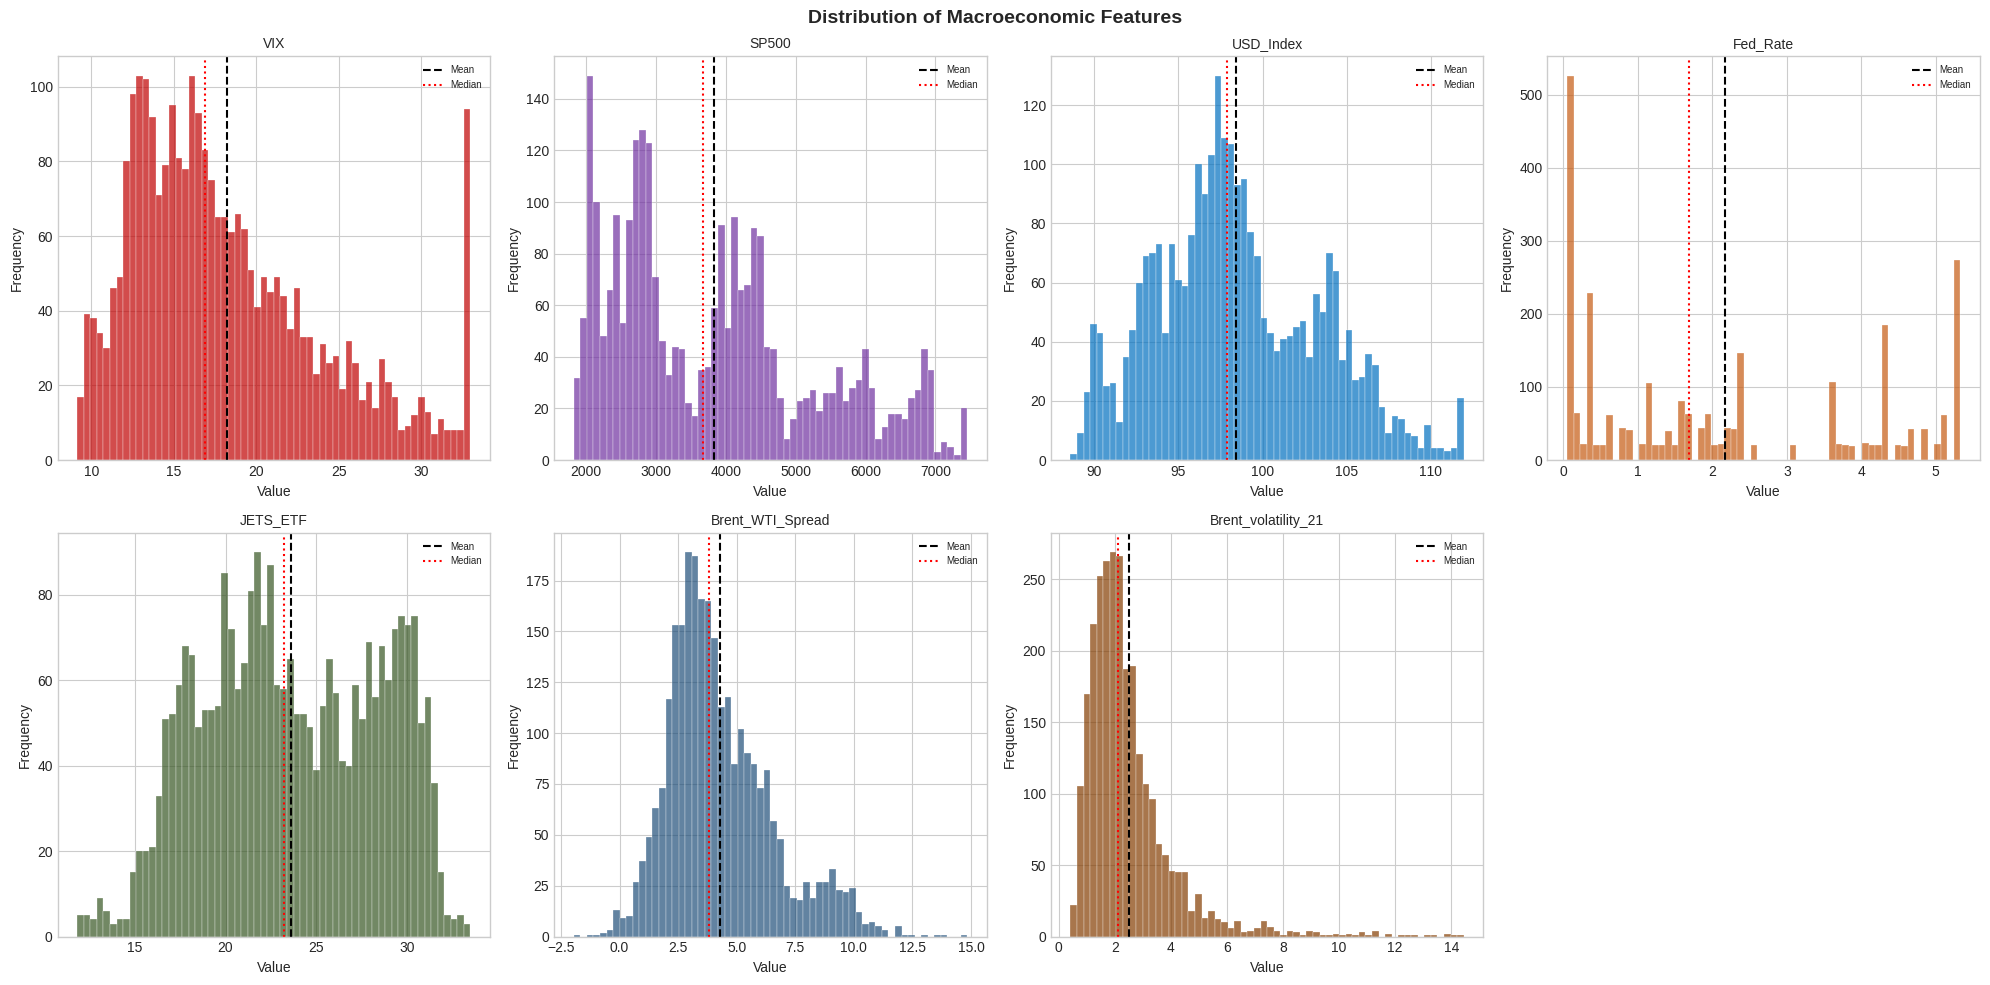

In [ ]:
new_feat_cols = ['VIX', 'SP500', 'USD_Index',
                 'Fed_Rate', 'JETS_ETF',
                 'Brent_WTI_Spread', 'Brent_volatility_21']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

colors = ['#c00000', '#7030a0', '#0070c0',
          '#c55a11', '#375623', '#1f4e79', '#833c00']

for i, (col, color) in enumerate(
        zip(new_feat_cols, colors)):
    axes[i].hist(df_clean[col], bins=60,
                 color=color, alpha=0.7,
                 edgecolor='white', linewidth=0.3)
    axes[i].axvline(df_clean[col].mean(),
                    color='black', linewidth=1.5,
                    linestyle='--', label='Mean')
    axes[i].axvline(df_clean[col].median(),
                    color='red', linewidth=1.5,
                    linestyle=':', label='Median')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=7)

axes[-1].axis('off')
plt.suptitle('Distribution of Macroeconomic Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distributions_macro.png',
            dpi=150, bbox_inches='tight')
plt.show()

**Correlation Heatmap**

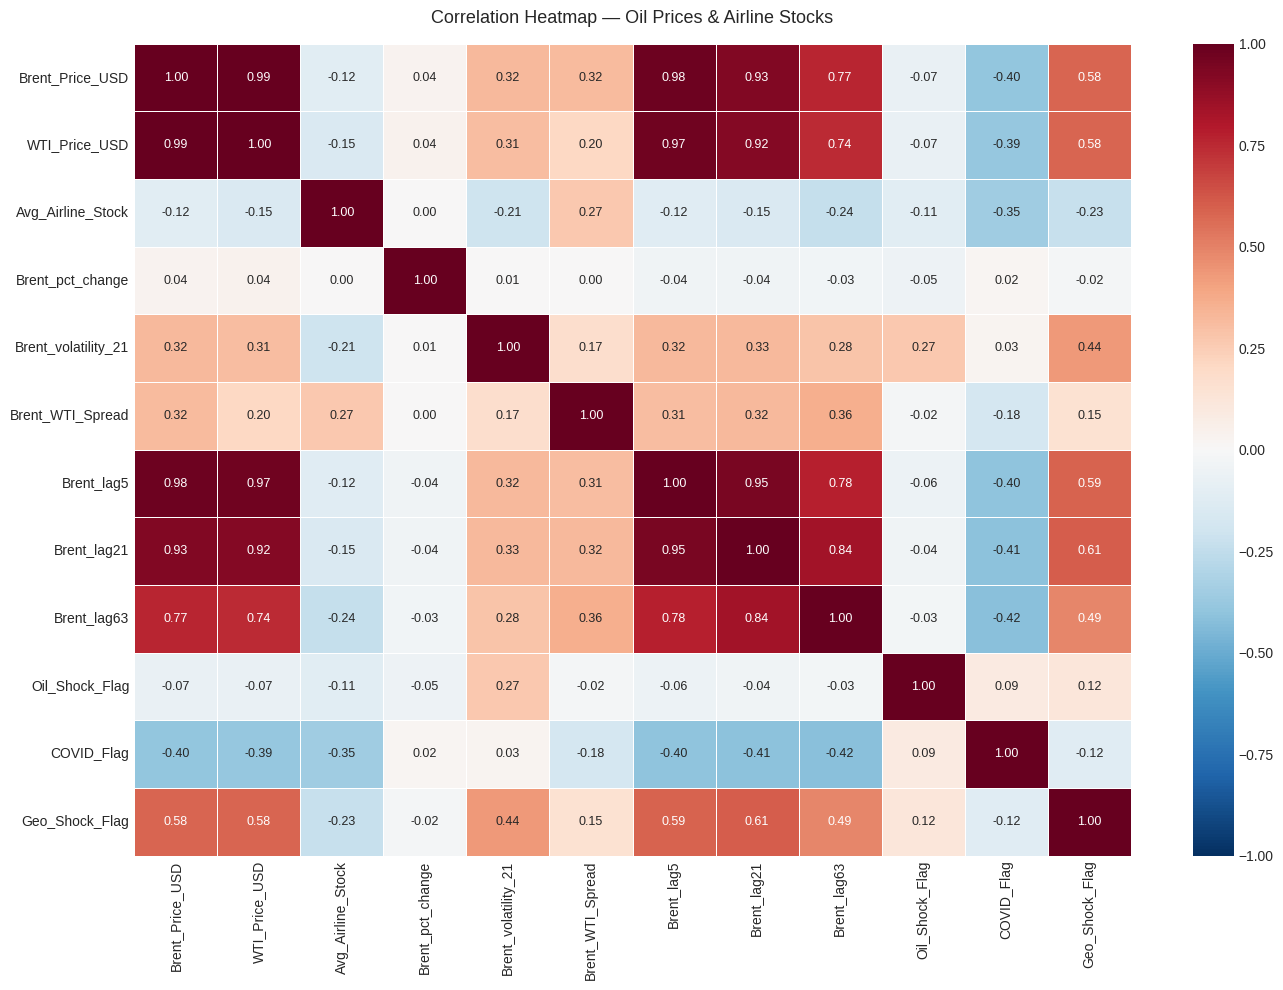

In [ ]:
corr_cols = ['Brent_Price_USD', 'WTI_Price_USD',
             'Avg_Airline_Stock', 'Brent_pct_change',
             'Brent_volatility_21', 'Brent_WTI_Spread',
             'Brent_lag5', 'Brent_lag21', 'Brent_lag63',
             'Oil_Shock_Flag', 'COVID_Flag', 'Geo_Shock_Flag']

corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            ax=ax,
            linewidths=0.5,
            annot_kws={'size': 9})

ax.set_title('Correlation Heatmap — Oil Prices & Airline Stocks',
             fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

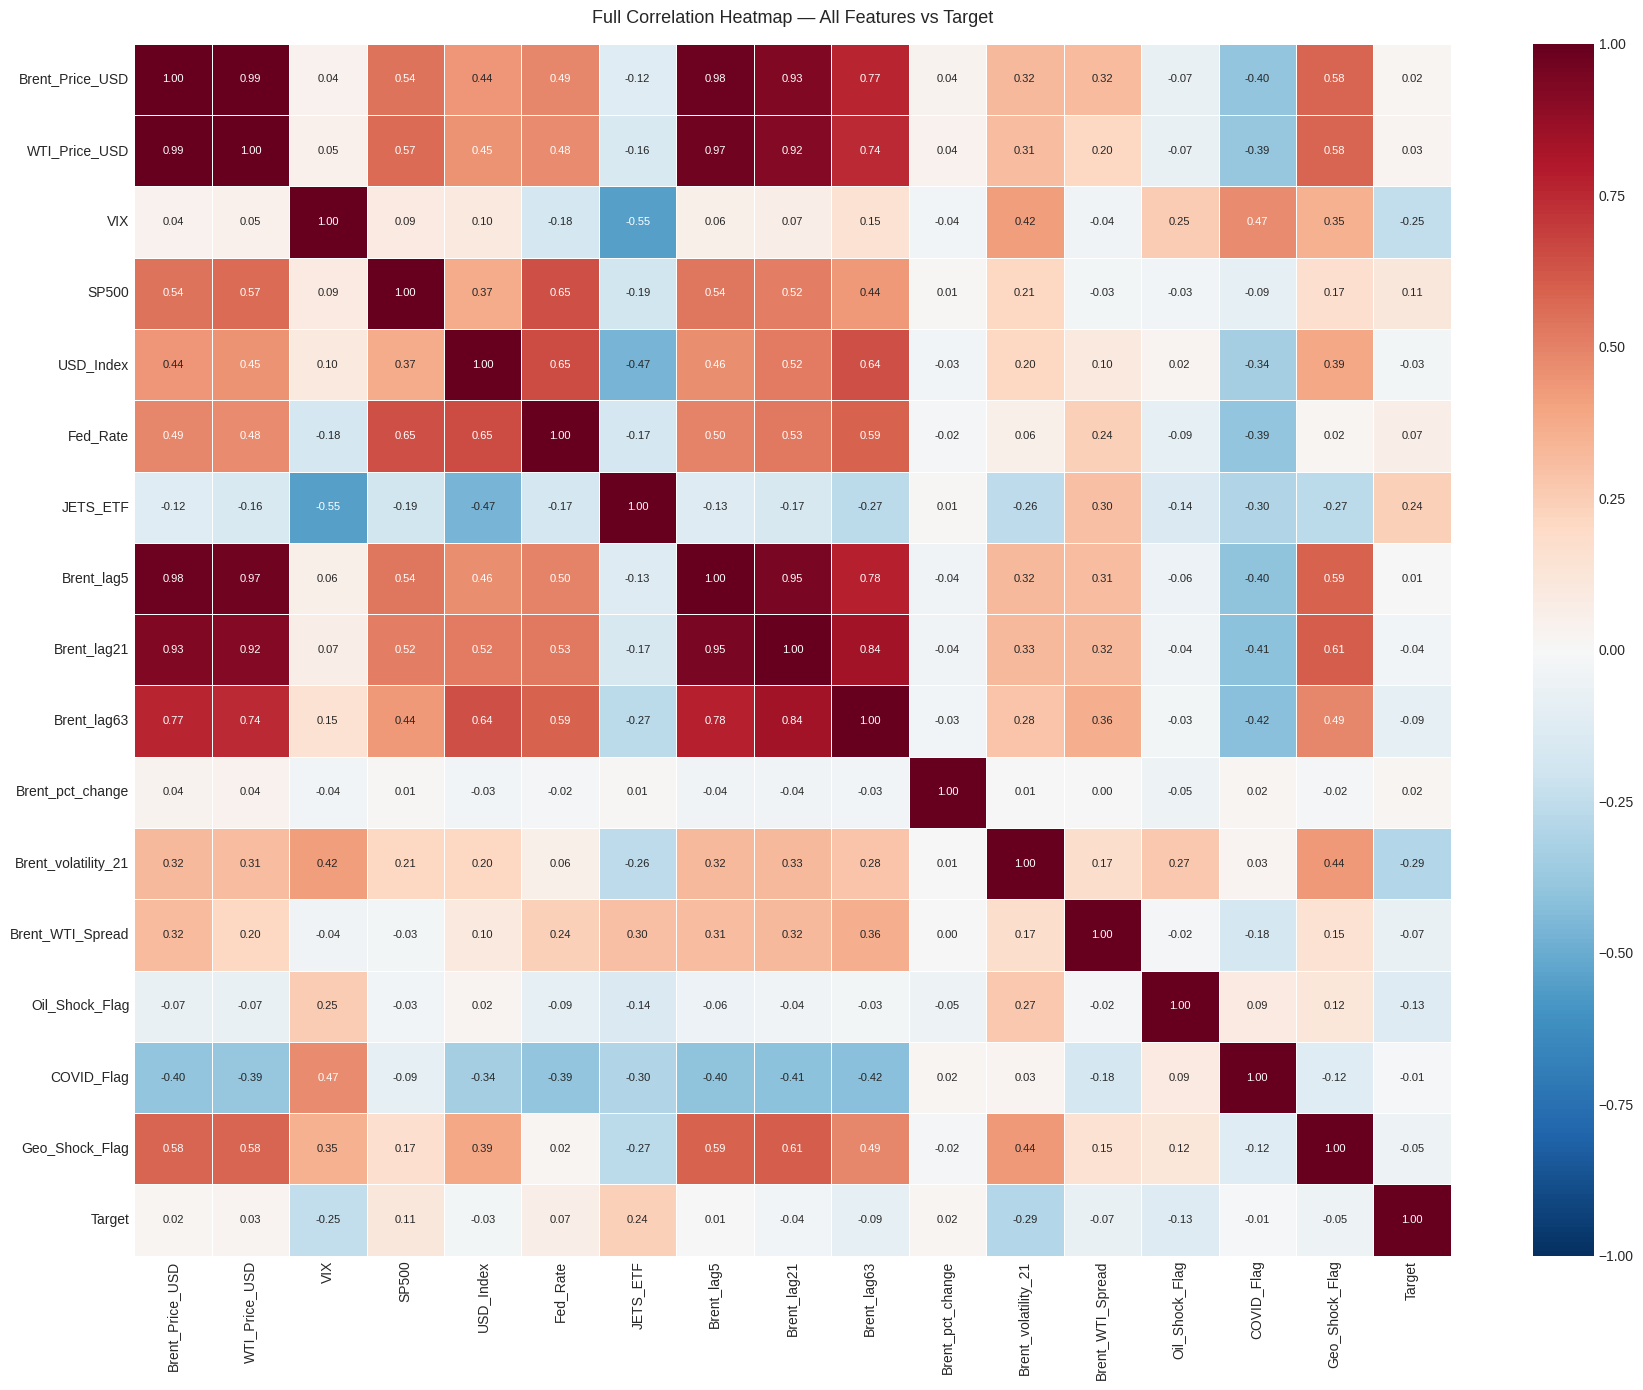

In [ ]:
#Extended Correlation Heatmap (all features including new ones)
corr_cols = ['Brent_Price_USD', 'WTI_Price_USD',
             'VIX', 'SP500', 'USD_Index',
             'Fed_Rate', 'JETS_ETF',
             'Brent_lag5', 'Brent_lag21', 'Brent_lag63',
             'Brent_pct_change', 'Brent_volatility_21',
             'Brent_WTI_Spread', 'Oil_Shock_Flag',
             'COVID_Flag', 'Geo_Shock_Flag', 'Target']

corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            ax=ax,
            linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Full Correlation Heatmap — '
             'All Features vs Target',
             fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap_full.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Check Brent_lag63 correlation with Target
corr_lag63 = df_clean['Brent_lag63'].corr(
    df_clean['Target'])
print(f"Brent_lag63 vs Target: {corr_lag63:.4f}")

# Also check all lag correlations together
for col in ['Brent_lag5', 'Brent_lag21', 'Brent_lag63']:
    r = df_clean[col].corr(df_clean['Target'])
    print(f"{col} vs Target: {r:.4f}")

Brent_lag63 vs Target: -0.0913
Brent_lag5 vs Target: 0.0052
Brent_lag21 vs Target: -0.0389
Brent_lag63 vs Target: -0.0913


**Oil Price vs Airline Stock Scatter**

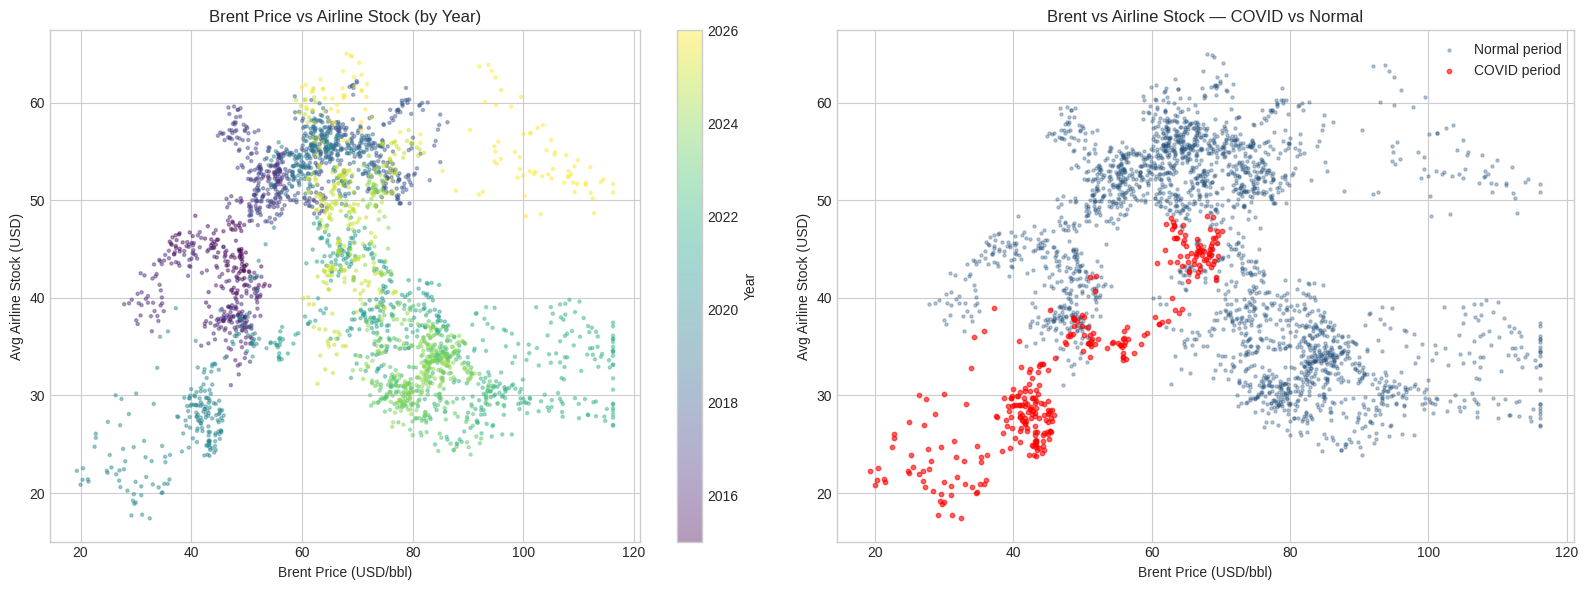

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Brent vs Avg Airline Stock — coloured by year
scatter1 = axes[0].scatter(df_clean['Brent_Price_USD'],
                            df_clean['Avg_Airline_Stock'],
                            c=df_clean['Year'],
                            cmap='viridis',
                            alpha=0.4, s=5)
plt.colorbar(scatter1, ax=axes[0], label='Year')
axes[0].set_xlabel('Brent Price (USD/bbl)')
axes[0].set_ylabel('Avg Airline Stock (USD)')
axes[0].set_title('Brent Price vs Airline Stock (by Year)')

# COVID vs Non-COVID comparison
covid_data    = df_clean[df_clean['COVID_Flag'] == 1]
noncovid_data = df_clean[df_clean['COVID_Flag'] == 0]

axes[1].scatter(noncovid_data['Brent_Price_USD'],
                noncovid_data['Avg_Airline_Stock'],
                color='#1f4e79', alpha=0.3, s=5,
                label='Normal period')
axes[1].scatter(covid_data['Brent_Price_USD'],
                covid_data['Avg_Airline_Stock'],
                color='red', alpha=0.6, s=10,
                label='COVID period')
axes[1].set_xlabel('Brent Price (USD/bbl)')
axes[1].set_ylabel('Avg Airline Stock (USD)')
axes[1].set_title('Brent vs Airline Stock — COVID vs Normal')
axes[1].legend()

plt.tight_layout()
plt.savefig('scatter_oil_airline.png', dpi=150, bbox_inches='tight')
plt.show()

**Cross Correlation (Lag Analysis for RQ1)**

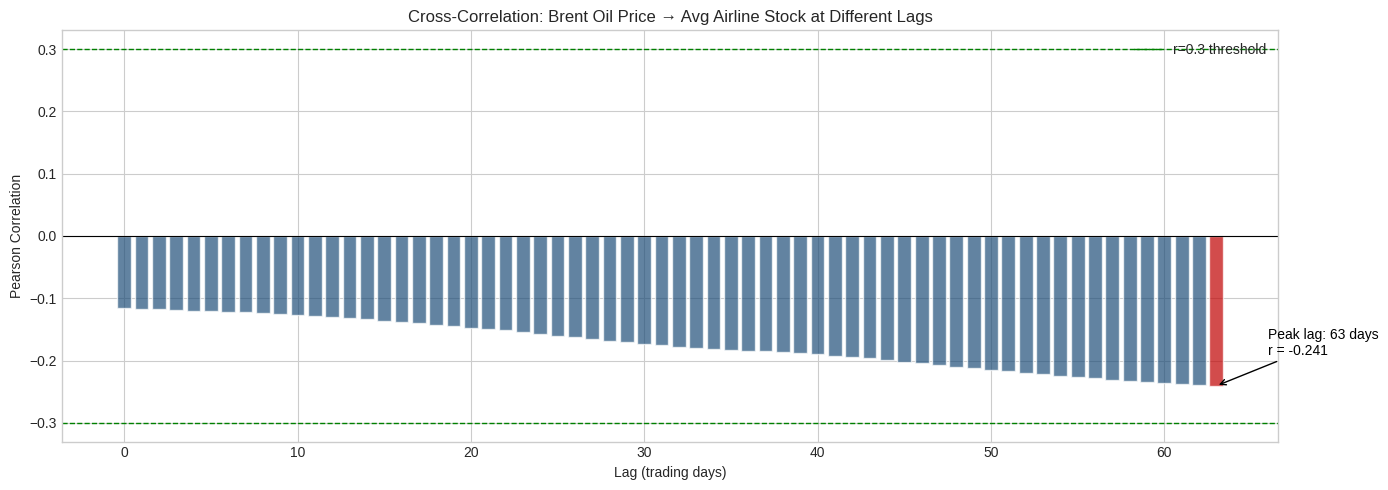

Peak correlation at lag 63 days: r = -0.241


In [ ]:
# This directly answers RQ1 — at which lag does oil price
# most strongly correlate with airline stock price?

from scipy import stats

lags = range(0, 64)
correlations = []

for lag in lags:
    shifted = df_clean['Brent_Price_USD'].shift(lag)
    valid = df_clean['Avg_Airline_Stock'].dropna()
    idx = valid.index.intersection(shifted.dropna().index)
    r, p = stats.pearsonr(shifted[idx], valid[idx])
    correlations.append({'Lag': lag, 'Correlation': r,
                         'P_value': p})

corr_df = pd.DataFrame(correlations)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(corr_df['Lag'], corr_df['Correlation'],
              color=['#c00000' if abs(c) ==
                     corr_df['Correlation'].abs().max()
                     else '#1f4e79'
                     for c in corr_df['Correlation']],
              alpha=0.7, edgecolor='white')

ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(0.3, color='green', linewidth=1,
           linestyle='--', label='r=0.3 threshold')
ax.axhline(-0.3, color='green', linewidth=1, linestyle='--')
ax.set_xlabel('Lag (trading days)')
ax.set_ylabel('Pearson Correlation')
ax.set_title('Cross-Correlation: Brent Oil Price → '
             'Avg Airline Stock at Different Lags')
ax.legend()

best_lag = corr_df.loc[corr_df['Correlation'].abs().idxmax()]
ax.annotate(f"Peak lag: {int(best_lag['Lag'])} days\n"
            f"r = {best_lag['Correlation']:.3f}",
            xy=(best_lag['Lag'], best_lag['Correlation']),
            xytext=(best_lag['Lag']+3, best_lag['Correlation']+0.05),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, color='black')

plt.tight_layout()
plt.savefig('cross_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Peak correlation at lag {int(best_lag['Lag'])} days: "
      f"r = {best_lag['Correlation']:.3f}")

**Oil Shock Events Analysis**

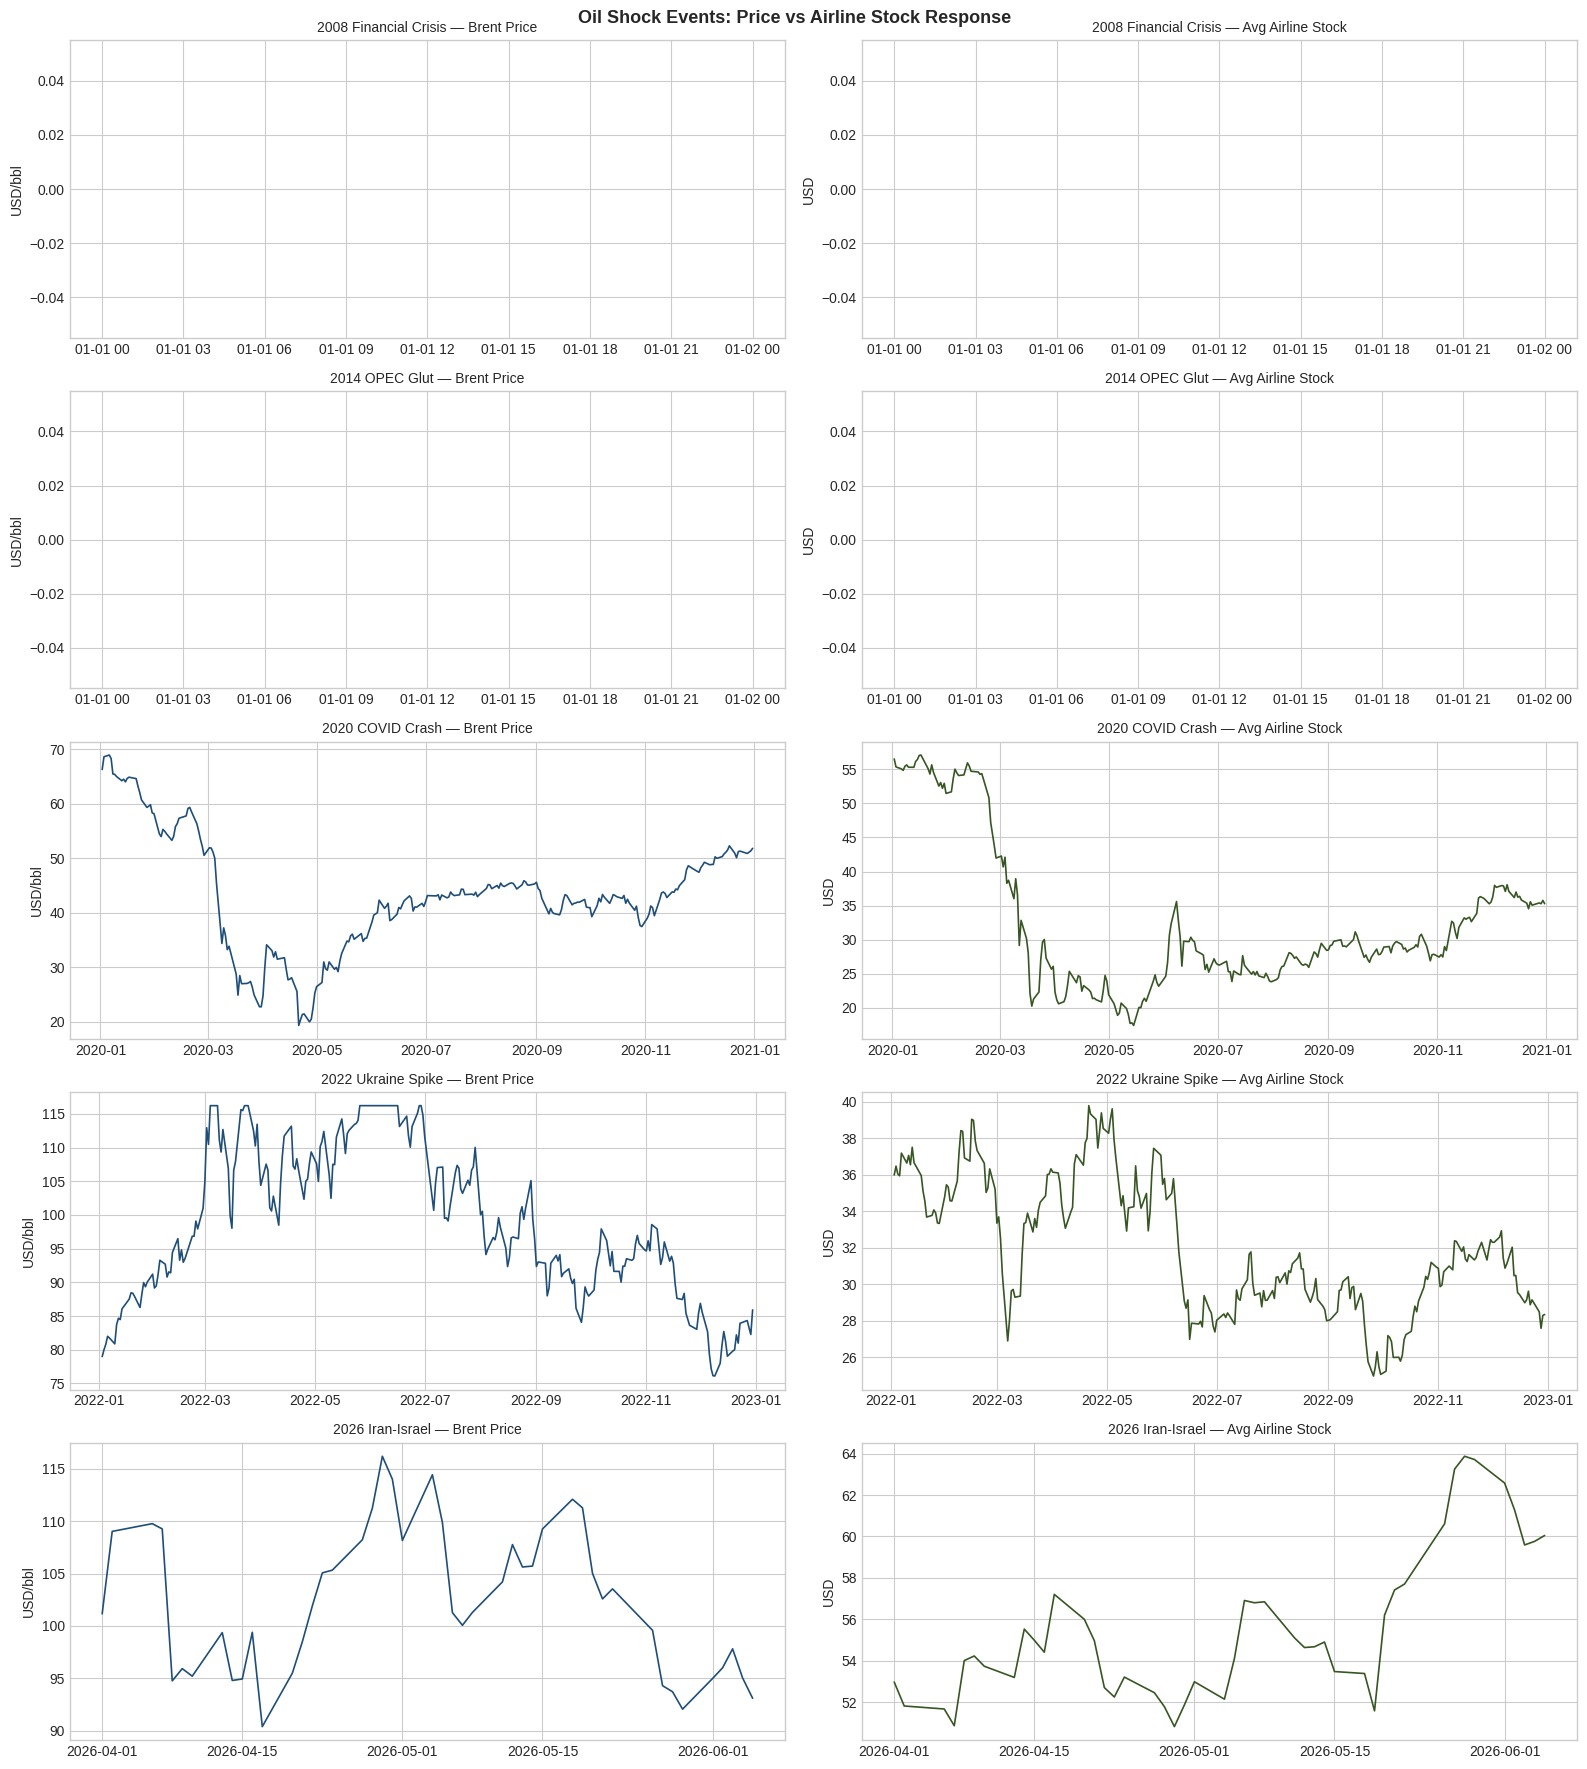

In [ ]:
# Show what happened to airline stocks after each major oil shock
# Directly supports RQ1 narrative

shocks = {
    '2008 Financial Crisis': ('2008-07-01', '2009-03-01'),
    '2014 OPEC Glut':        ('2014-06-01', '2015-06-01'),
    '2020 COVID Crash':      ('2020-01-01', '2021-01-01'),
    '2022 Ukraine Spike':    ('2022-01-01', '2022-12-31'),
    '2026 Iran-Israel':      ('2026-04-01', '2026-06-08')
}

fig, axes = plt.subplots(len(shocks), 2,
                          figsize=(16, 18))

for i, (name, (start, end)) in enumerate(shocks.items()):
    mask = (df_clean.index >= start) & (df_clean.index <= end)
    subset = df_clean[mask]

    axes[i][0].plot(subset.index,
                    subset['Brent_Price_USD'],
                    color='#1f4e79', linewidth=1.2)
    axes[i][0].set_title(f'{name} — Brent Price',
                          fontsize=10)
    axes[i][0].set_ylabel('USD/bbl')

    axes[i][1].plot(subset.index,
                    subset['Avg_Airline_Stock'],
                    color='#375623', linewidth=1.2)
    axes[i][1].set_title(f'{name} — Avg Airline Stock',
                          fontsize=10)
    axes[i][1].set_ylabel('USD')

plt.suptitle('Oil Shock Events: Price vs Airline Stock Response',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shock_events.png', dpi=150, bbox_inches='tight')
plt.show()

**Rolling Statistics Plot**

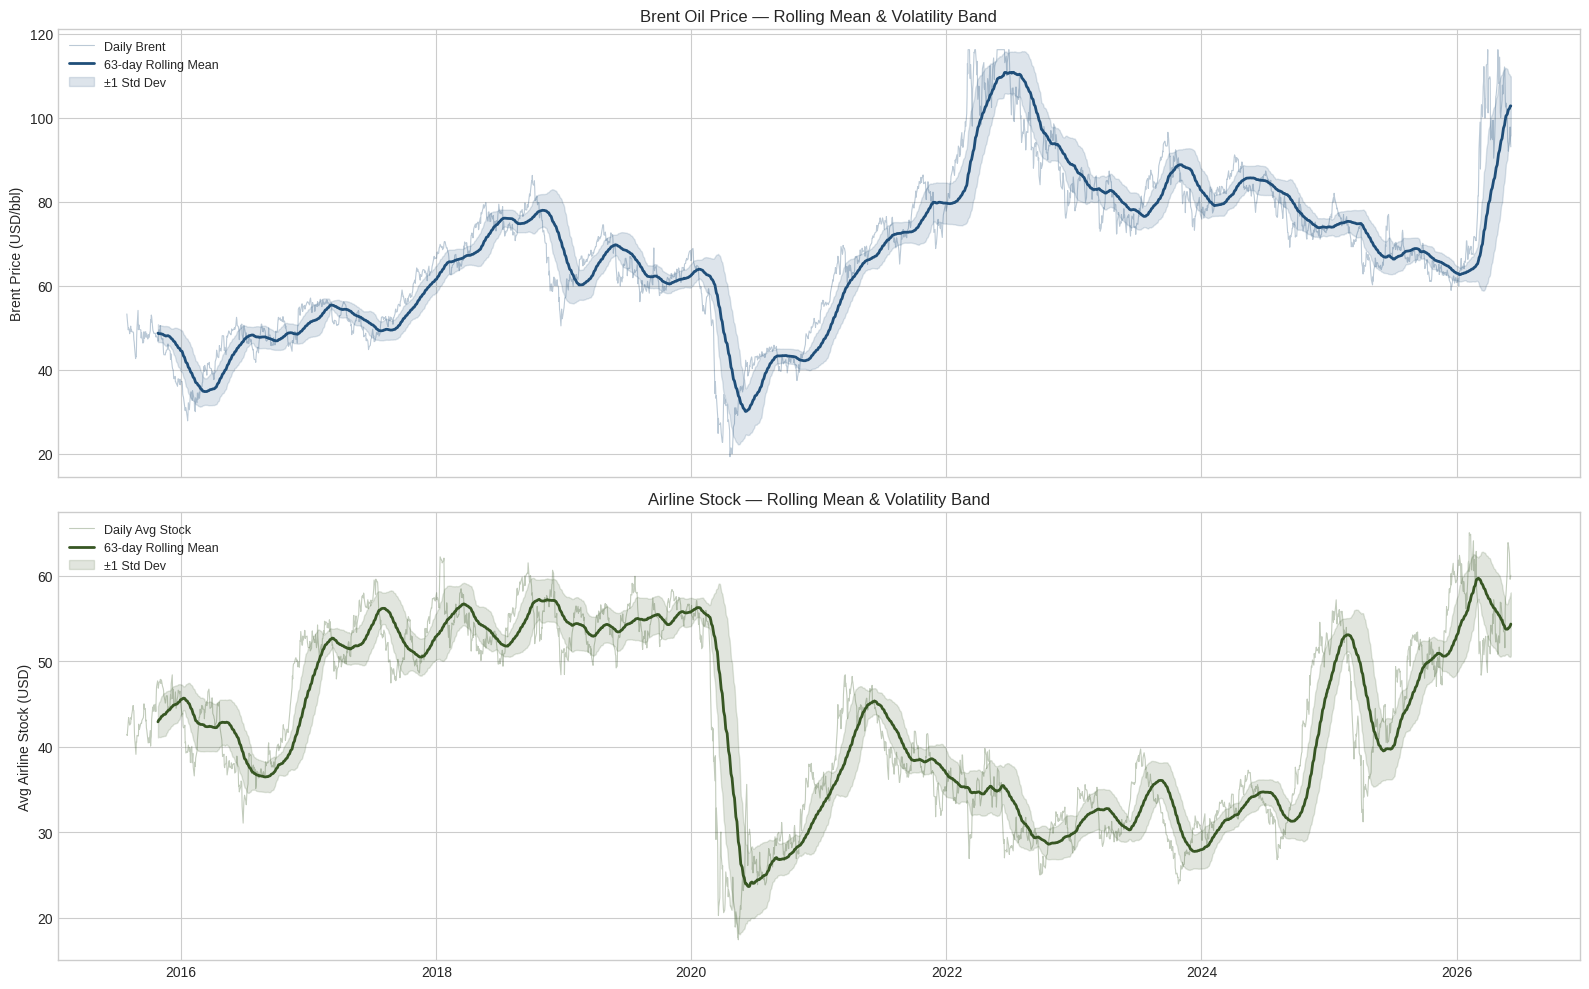

In [ ]:
# Rolling mean and volatility — shows changing dynamics over time

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Rolling 63-day (3 month) mean of Brent
rolling_mean = df_clean['Brent_Price_USD'].rolling(63).mean()
rolling_std  = df_clean['Brent_Price_USD'].rolling(63).std()

axes[0].plot(df_clean.index,
             df_clean['Brent_Price_USD'],
             color='#1f4e79', alpha=0.3,
             linewidth=0.8, label='Daily Brent')
axes[0].plot(df_clean.index, rolling_mean,
             color='#1f4e79', linewidth=2,
             label='63-day Rolling Mean')
axes[0].fill_between(df_clean.index,
                      rolling_mean - rolling_std,
                      rolling_mean + rolling_std,
                      alpha=0.15, color='#1f4e79',
                      label='±1 Std Dev')
axes[0].set_ylabel('Brent Price (USD/bbl)')
axes[0].set_title('Brent Oil Price — Rolling Mean & Volatility Band')
axes[0].legend(fontsize=9)

# Rolling 63-day mean of Airline Stock
roll_airline = df_clean['Avg_Airline_Stock'].rolling(63).mean()
roll_std_air = df_clean['Avg_Airline_Stock'].rolling(63).std()

axes[1].plot(df_clean.index,
             df_clean['Avg_Airline_Stock'],
             color='#375623', alpha=0.3,
             linewidth=0.8, label='Daily Avg Stock')
axes[1].plot(df_clean.index, roll_airline,
             color='#375623', linewidth=2,
             label='63-day Rolling Mean')
axes[1].fill_between(df_clean.index,
                      roll_airline - roll_std_air,
                      roll_airline + roll_std_air,
                      alpha=0.15, color='#375623',
                      label='±1 Std Dev')
axes[1].set_ylabel('Avg Airline Stock (USD)')
axes[1].set_title('Airline Stock — Rolling Mean & Volatility Band')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('rolling_stats.png', dpi=150, bbox_inches='tight')
plt.show()

**Prepare Fetaures and Target before Modeling**

In [ ]:
# Final feature selection based on correlation analysis
# Dropped: Brent_lag5 (0.009), USD_Index (-0.03),
#          Brent_pct_change (0.02), Brent_WTI_Spread (-0.08),
#          COVID_Flag (-0.01), Geo_Shock_Flag (-0.05)

feature_cols = [
    # Oil prices (baseline)
    'Brent_Price_USD', 'WTI_Price_USD',
    # Lag features (motivated by cross-correlation peak)
    'Brent_lag21', 'Brent_lag63',
    # Oil volatility (strongest oil feature r=-0.29)
    'Brent_volatility_21',
    # Shock indicator
    'Oil_Shock_Flag',
    # Macroeconomic features
    'VIX',       # r=-0.25 market fear
    'SP500',     # r=0.12  market trend
    'Fed_Rate',  # r=0.07  monetary policy
    'JETS_ETF',  # r=0.24  airline sector
    # Time features
    'Month', 'DOW'
]

target_col = 'Target'

print(f"Total features: {len(feature_cols)}")
print(f"Target: {target_col}")
print(f"\nFeature list:")
for i, f in enumerate(feature_cols, 1):
    r = df_clean[f].corr(df_clean[target_col])
    print(f"   {i:2}. {f:25} r={r:.4f}")
print(f"\nDataset shape: {df_clean.shape}")
print(f"Training samples available: {len(df_clean)}")

Total features: 12
Target: Target

Feature list:
    1. Brent_Price_USD           r=0.0171
    2. WTI_Price_USD             r=0.0269
    3. Brent_lag21               r=-0.0389
    4. Brent_lag63               r=-0.0913
    5. Brent_volatility_21       r=-0.2915
    6. Oil_Shock_Flag            r=-0.1305
    7. VIX                       r=-0.2488
    8. SP500                     r=0.1105
    9. Fed_Rate                  r=0.0693
   10. JETS_ETF                  r=0.2363
   11. Month                     r=0.1633
   12. DOW                       r=-0.0008

Dataset shape: (2727, 30)
Training samples available: 2727


DOW has r=-0.0007 — essentially zero. Dropping it

In [ ]:
feature_cols = [
    'Brent_Price_USD', 'WTI_Price_USD',
    'Brent_lag21', 'Brent_lag63',
    'Brent_volatility_21',
    'Oil_Shock_Flag',
    'VIX', 'SP500',
    'Fed_Rate', 'JETS_ETF',
    'Month'
]

target_col = 'Target'

print(f"Final features: {len(feature_cols)}")
print(f"Target: {target_col}")
print(f"\nFinal feature correlations with Target:")
for i, f in enumerate(feature_cols, 1):
    r = df_clean[f].corr(df_clean[target_col])
    print(f"   {i:2}. {f:25} r={r:.4f}")

Final features: 11
Target: Target

Final feature correlations with Target:
    1. Brent_Price_USD           r=0.0171
    2. WTI_Price_USD             r=0.0269
    3. Brent_lag21               r=-0.0389
    4. Brent_lag63               r=-0.0913
    5. Brent_volatility_21       r=-0.2915
    6. Oil_Shock_Flag            r=-0.1305
    7. VIX                       r=-0.2488
    8. SP500                     r=0.1105
    9. Fed_Rate                  r=0.0693
   10. JETS_ETF                  r=0.2363
   11. Month                     r=0.1633


**Normalize Data & Create Sequences**

In [ ]:
# Normalize features and target using MinMaxScaler
# LSTM requires normalized input (0-1 range)

from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(
    df_clean[feature_cols])
y_scaled = scaler_y.fit_transform(
    df_clean[[target_col]])

# Sequence length = 60 days
# Motivated by cross-correlation peak at 60 trading days
SEQUENCE_LENGTH = 60

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(
    X_scaled, y_scaled, SEQUENCE_LENGTH)

print(f"Sequence length: {SEQUENCE_LENGTH} days")
print(f"X sequences shape: {X_seq.shape}")
print(f"y sequences shape: {y_seq.shape}")
print(f"Each sample: {SEQUENCE_LENGTH} days "
      f"x {len(feature_cols)} features")

Sequence length: 60 days
X sequences shape: (2667, 60, 11)
y sequences shape: (2667, 1)
Each sample: 60 days x 11 features


**Train/Test Split**

In [ ]:
# 80% train, 20% test — chronological split (no shuffling!)
# Time series must be split in order — no random shuffling


TRAIN_RATIO = 0.80
split_idx = int(len(X_seq) * TRAIN_RATIO)

X_train = X_seq[:split_idx]
X_test  = X_seq[split_idx:]
y_train = y_seq[:split_idx]
y_test  = y_seq[split_idx:]

print(f"Total sequences:   {len(X_seq)}")
print(f"Training samples:  {len(X_train)}")
print(f"Testing samples:   {len(X_test)}")
print(f"Train period: "
      f"{df_clean.index[SEQUENCE_LENGTH]} to "
      f"{df_clean.index[split_idx+SEQUENCE_LENGTH]}")
print(f"Test period:  "
      f"{df_clean.index[split_idx+SEQUENCE_LENGTH]} to "
      f"{df_clean.index[-1]}")

Total sequences:   2667
Training samples:  2133
Testing samples:   534
Train period: 2015-10-23 00:00:00 to 2024-04-19 00:00:00
Test period:  2024-04-19 00:00:00 to 2026-06-05 00:00:00


**Convert to PyTorch Tensors**

In [ ]:
# Convert numpy arrays to PyTorch tensors and create DataLoaders

X_train_t = torch.FloatTensor(X_train)
X_test_t  = torch.FloatTensor(X_test)
y_train_t = torch.FloatTensor(y_train)
y_test_t  = torch.FloatTensor(y_test)

BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_dataset,
                           batch_size=BATCH_SIZE,
                           shuffle=False)
test_loader  = DataLoader(test_dataset,
                           batch_size=BATCH_SIZE,
                           shuffle=False)

print(f"X_train tensor: {X_train_t.shape}")
print(f"X_test tensor:  {X_test_t.shape}")
print(f"y_train tensor: {y_train_t.shape}")
print(f"y_test tensor:  {y_test_t.shape}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training batches: {len(train_loader)}")
print(f"Testing batches:  {len(test_loader)}")

X_train tensor: torch.Size([2133, 60, 11])
X_test tensor:  torch.Size([534, 60, 11])
y_train tensor: torch.Size([2133, 1])
y_test tensor:  torch.Size([534, 1])
Batch size: 32
Training batches: 67
Testing batches:  17


**Build LSTM with Attention Model**

In [ ]:
# LSTM with Attention Mechanism
# Pipeline 1 — Baseline model

class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, lstm_output):
        attn_weights = torch.softmax(
            self.attention(lstm_output), dim=1)
        context = torch.sum(
            attn_weights * lstm_output, dim=1)
        return context, attn_weights


class LSTMAttention(nn.Module):
    def __init__(self, input_size, hidden_size,
                 num_layers, dropout):
        super(LSTMAttention, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0)
        self.attention = Attention(hidden_size)
        self.dropout   = nn.Dropout(dropout)
        self.fc1       = nn.Linear(hidden_size, 64)
        self.relu      = nn.ReLU()
        self.fc2       = nn.Linear(64, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        context, attn_weights = self.attention(lstm_out)
        out = self.dropout(context)
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out, attn_weights


INPUT_SIZE  = len(feature_cols)
HIDDEN_SIZE = 128
NUM_LAYERS  = 2
DROPOUT     = 0.2

model_lstm = LSTMAttention(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT)

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu')
model_lstm = model_lstm.to(device)

total_params = sum(p.numel()
    for p in model_lstm.parameters()
    if p.requires_grad)
print(f"Device: {device}")
print(f"Model Architecture:\n{model_lstm}")
print(f"\nTotal trainable parameters: {total_params:,}")

Device: cpu
Model Architecture:
LSTMAttention(
  (lstm): LSTM(11, 128, num_layers=2, batch_first=True, dropout=0.2)
  (attention): Attention(
    (attention): Linear(in_features=128, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)

Total trainable parameters: 212,738


**Train LSTM Model**

In [ ]:
# Training LSTM-Attention Model

EPOCHS   = 100
LR       = 0.001
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model_lstm.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler\
    .ReduceLROnPlateau(optimizer,
                       patience=8, factor=0.5)

best_val_loss    = float('inf')
patience_counter = 0
PATIENCE         = 20

train_losses = []
val_losses   = []

for epoch in range(EPOCHS):
    model_lstm.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        output, _ = model_lstm(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model_lstm.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    model_lstm.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            output, _ = model_lstm(X_batch)
            loss = criterion(output, y_batch)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss   /= len(test_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_lstm.state_dict(),
                   'best_lstm_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Train: {train_loss:.6f} | "
              f"Val: {val_loss:.6f}")

print(f"\nBest val loss: {best_val_loss:.6f}")
print(f"Total epochs: {len(train_losses)}")

Epoch 10/100 | Train: 0.014276 | Val: 0.015003
Epoch 20/100 | Train: 0.012644 | Val: 0.011629
Epoch 30/100 | Train: 0.012174 | Val: 0.011788
Epoch 40/100 | Train: 0.011470 | Val: 0.018646
Early stopping at epoch 45

Best val loss: 0.010750
Total epochs: 45


**Evaluate**

LSTM-Attention Results:
MAE:  7.2173%
RMSE: 8.8346%
R2:   0.2459
MAPE: 193.0155%


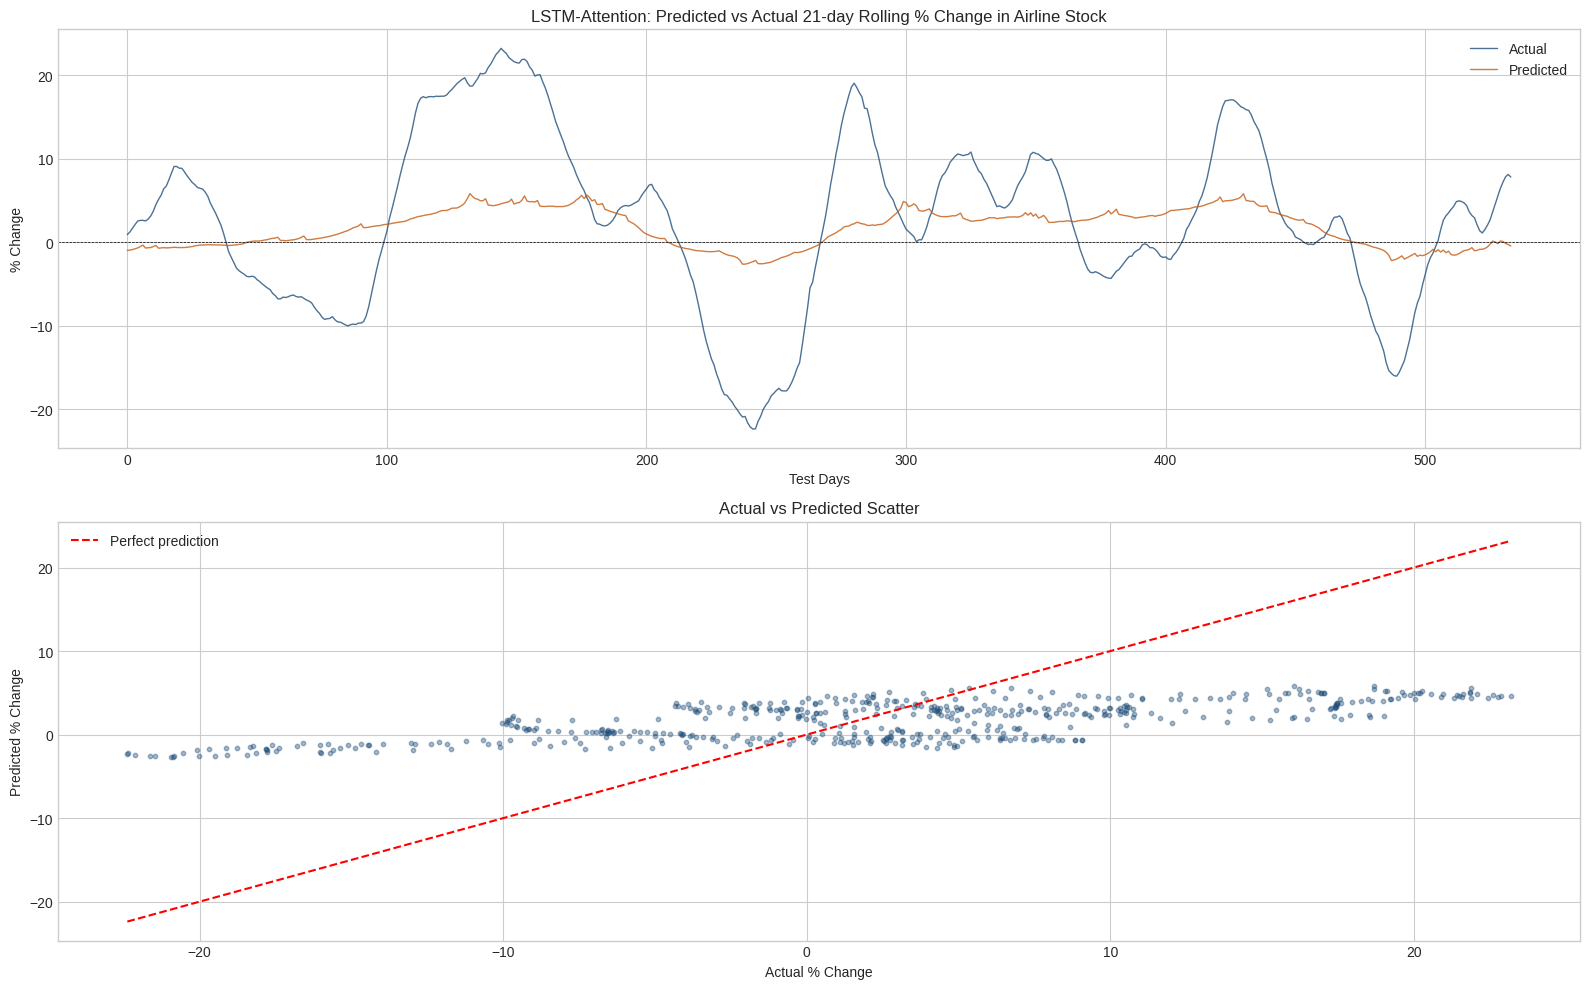

In [ ]:
# Load best model and evaluate

model_lstm.load_state_dict(
    torch.load('best_lstm_model.pth'))
model_lstm.eval()

predictions = []
actuals     = []
attention_weights_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        output, attn = model_lstm(X_batch)
        predictions.extend(output.cpu().numpy())
        actuals.extend(y_batch.numpy())
        attention_weights_list.extend(
            attn.cpu().numpy())

# Inverse transform
predictions = scaler_y.inverse_transform(
    np.array(predictions))
actuals     = scaler_y.inverse_transform(
    np.array(actuals))

# Metrics
mae  = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
r2   = r2_score(actuals, predictions)
mape = np.mean(np.abs(
    (actuals - predictions) /
    (np.abs(actuals) + 1e-8))) * 100

print("=" * 45)
print("LSTM-Attention Results:")
print("=" * 45)
print(f"MAE:  {mae:.4f}%")
print(f"RMSE: {rmse:.4f}%")
print(f"R2:   {r2:.4f}")
print(f"MAPE: {mape:.4f}%")
print("=" * 45)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(actuals, color='#1f4e79',
             linewidth=1, label='Actual', alpha=0.8)
axes[0].plot(predictions, color='#c55a11',
             linewidth=1, label='Predicted', alpha=0.8)
axes[0].axhline(0, color='black',
                linewidth=0.5, linestyle='--')
axes[0].set_title('LSTM-Attention: Predicted vs Actual '
                  '21-day Rolling % Change in Airline Stock')
axes[0].set_xlabel('Test Days')
axes[0].set_ylabel('% Change')
axes[0].legend()

axes[1].scatter(actuals, predictions,
                alpha=0.4, s=10, color='#1f4e79')
axes[1].plot([actuals.min(), actuals.max()],
             [actuals.min(), actuals.max()],
             'r--', linewidth=1.5,
             label='Perfect prediction')
axes[1].set_xlabel('Actual % Change')
axes[1].set_ylabel('Predicted % Change')
axes[1].set_title('Actual vs Predicted Scatter')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_results.png',
            dpi=150, bbox_inches='tight')
plt.show()

**Tunning the Model To improve R²**

In [ ]:
# Retrain with tuned hyperparameters
# Larger hidden size + more layers + lower LR
# Fixed seed + Tuned Transformer architecture
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

model_transformer2 = TransformerModel(
    input_size=INPUT_SIZE,
    d_model=128,
    nhead=4,
    num_layers=4,
    dim_feedforward=512,
    dropout=0.1).to(device)

criterion_t2 = nn.MSELoss()
optimizer_t2 = torch.optim.AdamW(
    model_transformer2.parameters(),
    lr=0.0003, weight_decay=0.01)
scheduler_t2 = torch.optim.lr_scheduler\
    .ReduceLROnPlateau(optimizer_t2,
                       patience=10, factor=0.5)

best_val_t2        = float('inf')
patience_counter_t2 = 0
PATIENCE_T2        = 30
EPOCHS_T2          = 200

train_losses_t2 = []
val_losses_t2   = []

for epoch in range(EPOCHS_T2):
    model_transformer2.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer_t2.zero_grad()
        output = model_transformer2(X_batch)
        loss = criterion_t2(output, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model_transformer2.parameters(),
            max_norm=1.0)
        optimizer_t2.step()
        train_loss += loss.item()

    model_transformer2.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            output = model_transformer2(X_batch)
            loss = criterion_t2(output, y_batch)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss   /= len(test_loader)
    train_losses_t2.append(train_loss)
    val_losses_t2.append(val_loss)
    scheduler_t2.step(val_loss)

    if val_loss < best_val_t2:
        best_val_t2 = val_loss
        torch.save(model_transformer2.state_dict(),
                   'best_transformer2_model.pth')
        patience_counter_t2 = 0
    else:
        patience_counter_t2 += 1

    if patience_counter_t2 >= PATIENCE_T2:
        print(f"Early stopping at epoch {epoch+1}")
        break

    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS_T2} | "
              f"Train: {train_loss:.6f} | "
              f"Val: {val_loss:.6f}")

print(f"\nBest val loss: {best_val_t2:.6f}")
print(f"Total epochs: {len(train_losses_t2)}")

Epoch 20/200 | Train: 0.012563 | Val: 0.011196
Epoch 40/200 | Train: 0.003584 | Val: 0.002665
Epoch 60/200 | Train: 0.001576 | Val: 0.005010
Early stopping at epoch 77

Best val loss: 0.002593
Total epochs: 77


LSTM-Attention Tuned Results:
MAE:  7.6425%
RMSE: 9.3178%
R2:   0.1612

Model Comparison:
Metric          LSTM v1   LSTM v2 Tuned
--------------------------------------
MAE              7.2173          7.6425
RMSE             8.8346          9.3178
R2               0.2459          0.1612


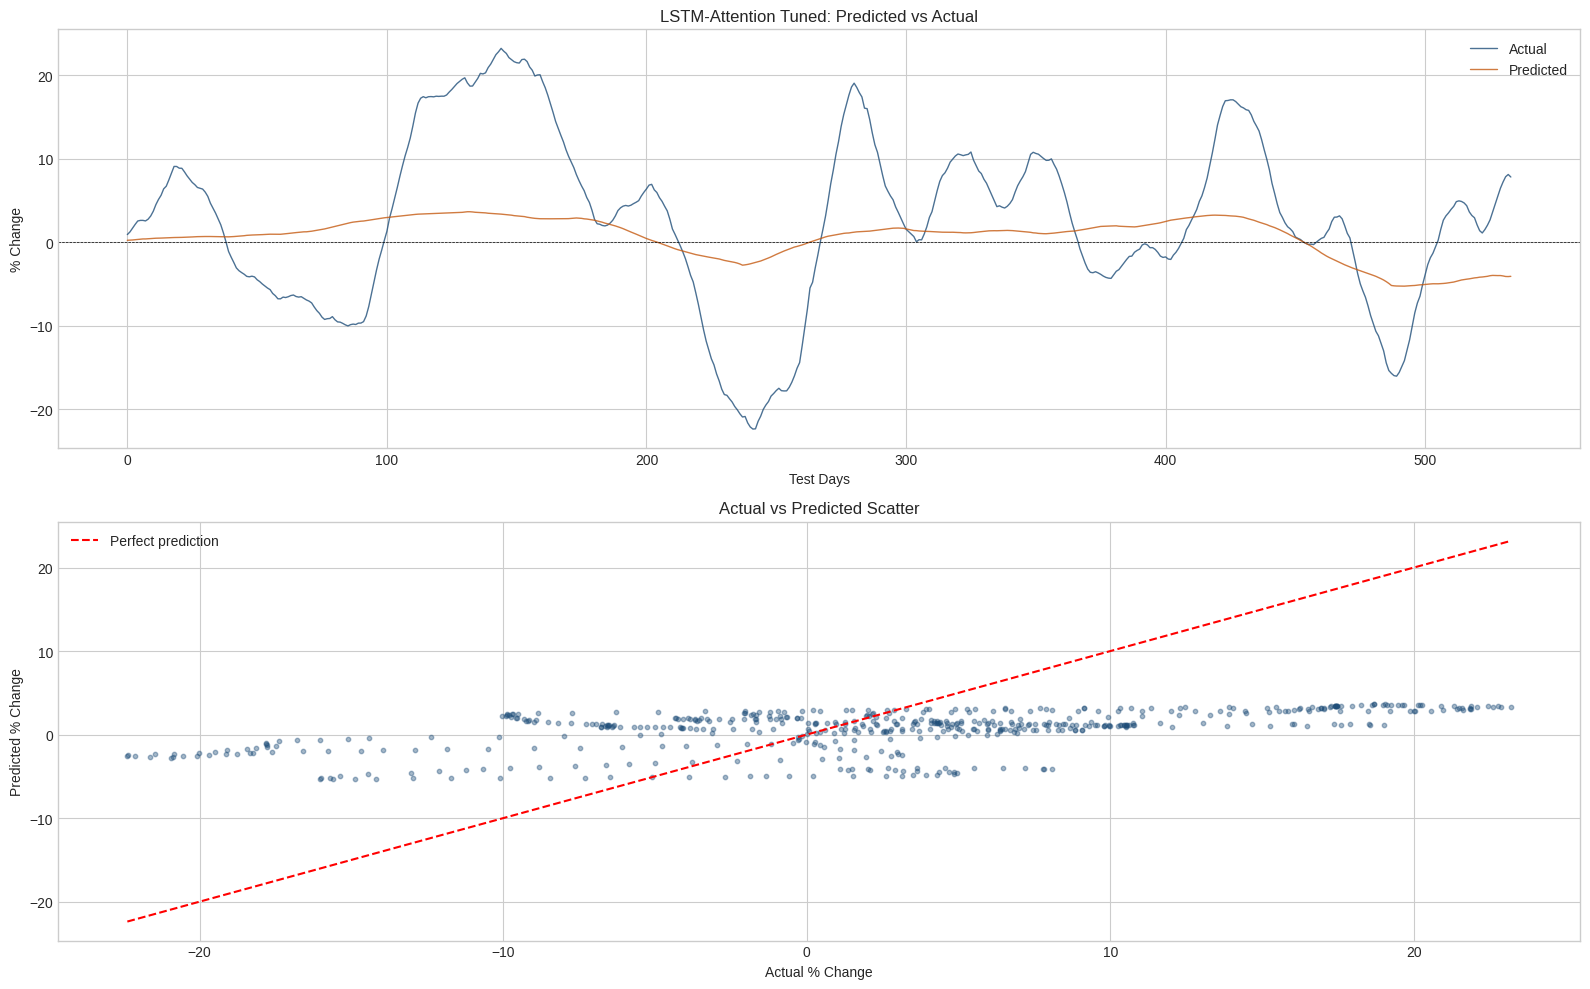

In [ ]:
# Evaluate tuned LSTM model

model_lstm2.load_state_dict(
    torch.load('best_lstm2_model.pth'))
model_lstm2.eval()

predictions2 = []
actuals2     = []
attn_weights2 = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        output, attn = model_lstm2(X_batch)
        predictions2.extend(output.cpu().numpy())
        actuals2.extend(y_batch.numpy())
        attn_weights2.extend(attn.cpu().numpy())

predictions2 = scaler_y.inverse_transform(
    np.array(predictions2))
actuals2     = scaler_y.inverse_transform(
    np.array(actuals2))

mae2  = mean_absolute_error(actuals2, predictions2)
rmse2 = np.sqrt(mean_squared_error(actuals2, predictions2))
r2_2  = r2_score(actuals2, predictions2)

print("=" * 45)
print("LSTM-Attention Tuned Results:")
print("=" * 45)
print(f"MAE:  {mae2:.4f}%")
print(f"RMSE: {rmse2:.4f}%")
print(f"R2:   {r2_2:.4f}")
print("=" * 45)

# Compare both models
print("\nModel Comparison:")
print(f"{'Metric':<10} {'LSTM v1':>12} {'LSTM v2 Tuned':>15}")
print("-" * 38)
print(f"{'MAE':<10} {mae:>12.4f} {mae2:>15.4f}")
print(f"{'RMSE':<10} {rmse:>12.4f} {rmse2:>15.4f}")
print(f"{'R2':<10} {r2:>12.4f} {r2_2:>15.4f}")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(actuals2, color='#1f4e79',
             linewidth=1, label='Actual', alpha=0.8)
axes[0].plot(predictions2, color='#c55a11',
             linewidth=1, label='Predicted', alpha=0.8)
axes[0].axhline(0, color='black',
                linewidth=0.5, linestyle='--')
axes[0].set_title('LSTM-Attention Tuned: '
                  'Predicted vs Actual')
axes[0].set_xlabel('Test Days')
axes[0].set_ylabel('% Change')
axes[0].legend()

axes[1].scatter(actuals2, predictions2,
                alpha=0.4, s=10, color='#1f4e79')
axes[1].plot([actuals2.min(), actuals2.max()],
             [actuals2.min(), actuals2.max()],
             'r--', linewidth=1.5,
             label='Perfect prediction')
axes[1].set_xlabel('Actual % Change')
axes[1].set_ylabel('Predicted % Change')
axes[1].set_title('Actual vs Predicted Scatter')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_tuned_results.png',
            dpi=150, bbox_inches='tight')
plt.show()

**Pipeline 2: Transformer**

In [ ]:
# Pipeline 2 — Transformer Model
# Multi-head self-attention for long-range dependencies

class TransformerModel(nn.Module):
    def __init__(self, input_size, d_model,
                 nhead, num_layers,
                 dim_feedforward, dropout):
        super(TransformerModel, self).__init__()

        # Input projection
        self.input_projection = nn.Linear(
            input_size, d_model)

        # Positional encoding
        self.pos_encoding = nn.Parameter(
            torch.randn(1, 500, d_model))

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True)

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers)

        # Output layers
        self.dropout = nn.Dropout(dropout)
        self.fc1     = nn.Linear(d_model, 64)
        self.relu    = nn.ReLU()
        self.fc2     = nn.Linear(64, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        x = self.input_projection(x)
        x = x + self.pos_encoding[
            :, :x.size(1), :]
        x = self.transformer(x)
        # Use last timestep
        x = x[:, -1, :]
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# Model parameters
D_MODEL       = 64
NHEAD         = 4
NUM_LAYERS_T  = 3
DIM_FF        = 256
DROPOUT_T     = 0.2

model_transformer = TransformerModel(
    input_size=INPUT_SIZE,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS_T,
    dim_feedforward=DIM_FF,
    dropout=DROPOUT_T).to(device)

total_params_t = sum(
    p.numel()
    for p in model_transformer.parameters()
    if p.requires_grad)

print(f"Transformer Architecture:")
print(model_transformer)
print(f"\nTotal parameters: {total_params_t:,}")

Transformer Architecture:
TransformerModel(
  (input_projection): Linear(in_features=11, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)

In [ ]:
# Fix seeds for reproducibility
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Same architecture as original Transformer v1
model_transformer = TransformerModel(
    input_size=INPUT_SIZE,
    d_model=64,
    nhead=4,
    num_layers=3,
    dim_feedforward=256,
    dropout=0.2).to(device)

criterion_t = nn.MSELoss()
optimizer_t = torch.optim.AdamW(
    model_transformer.parameters(),
    lr=0.0005, weight_decay=0.01)
scheduler_t = torch.optim.lr_scheduler\
    .ReduceLROnPlateau(optimizer_t,
                       patience=8, factor=0.5)

best_val_t        = float('inf')
patience_counter_t = 0
PATIENCE_T        = 25
EPOCHS_T          = 150

train_losses_t = []
val_losses_t   = []

for epoch in range(EPOCHS_T):
    model_transformer.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer_t.zero_grad()
        output = model_transformer(X_batch)
        loss = criterion_t(output, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model_transformer.parameters(),
            max_norm=1.0)
        optimizer_t.step()
        train_loss += loss.item()

    model_transformer.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            output = model_transformer(X_batch)
            loss = criterion_t(output, y_batch)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss   /= len(test_loader)
    train_losses_t.append(train_loss)
    val_losses_t.append(val_loss)
    scheduler_t.step(val_loss)

    if val_loss < best_val_t:
        best_val_t = val_loss
        torch.save(model_transformer.state_dict(),
                   'best_transformer_model.pth')
        patience_counter_t = 0
    else:
        patience_counter_t += 1

    if patience_counter_t >= PATIENCE_T:
        print(f"Early stopping at epoch {epoch+1}")
        break

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS_T} | "
              f"Train: {train_loss:.6f} | "
              f"Val: {val_loss:.6f}")

print(f"\nBest val loss: {best_val_t:.6f}")
print(f"Total epochs: {len(train_losses_t)}")

Epoch 10/150 | Train: 0.013069 | Val: 0.022322
Epoch 20/150 | Train: 0.010290 | Val: 0.013058
Epoch 30/150 | Train: 0.005905 | Val: 0.010587
Epoch 40/150 | Train: 0.004174 | Val: 0.009621
Epoch 50/150 | Train: 0.002988 | Val: 0.008932
Epoch 60/150 | Train: 0.001959 | Val: 0.009855
Early stopping at epoch 69

Best val loss: 0.005576
Total epochs: 69


**Evaluate**

Transformer Results:
MAE:  5.2628%
RMSE: 6.3685%
R2:   0.6081

Final Model Comparison:
Metric        LSTM v1   LSTM Tuned   Transformer
------------------------------------------------
MAE            7.2173       7.6425        5.2628
RMSE           8.8346       9.3178        6.3685
R2             0.2459       0.1612        0.6081


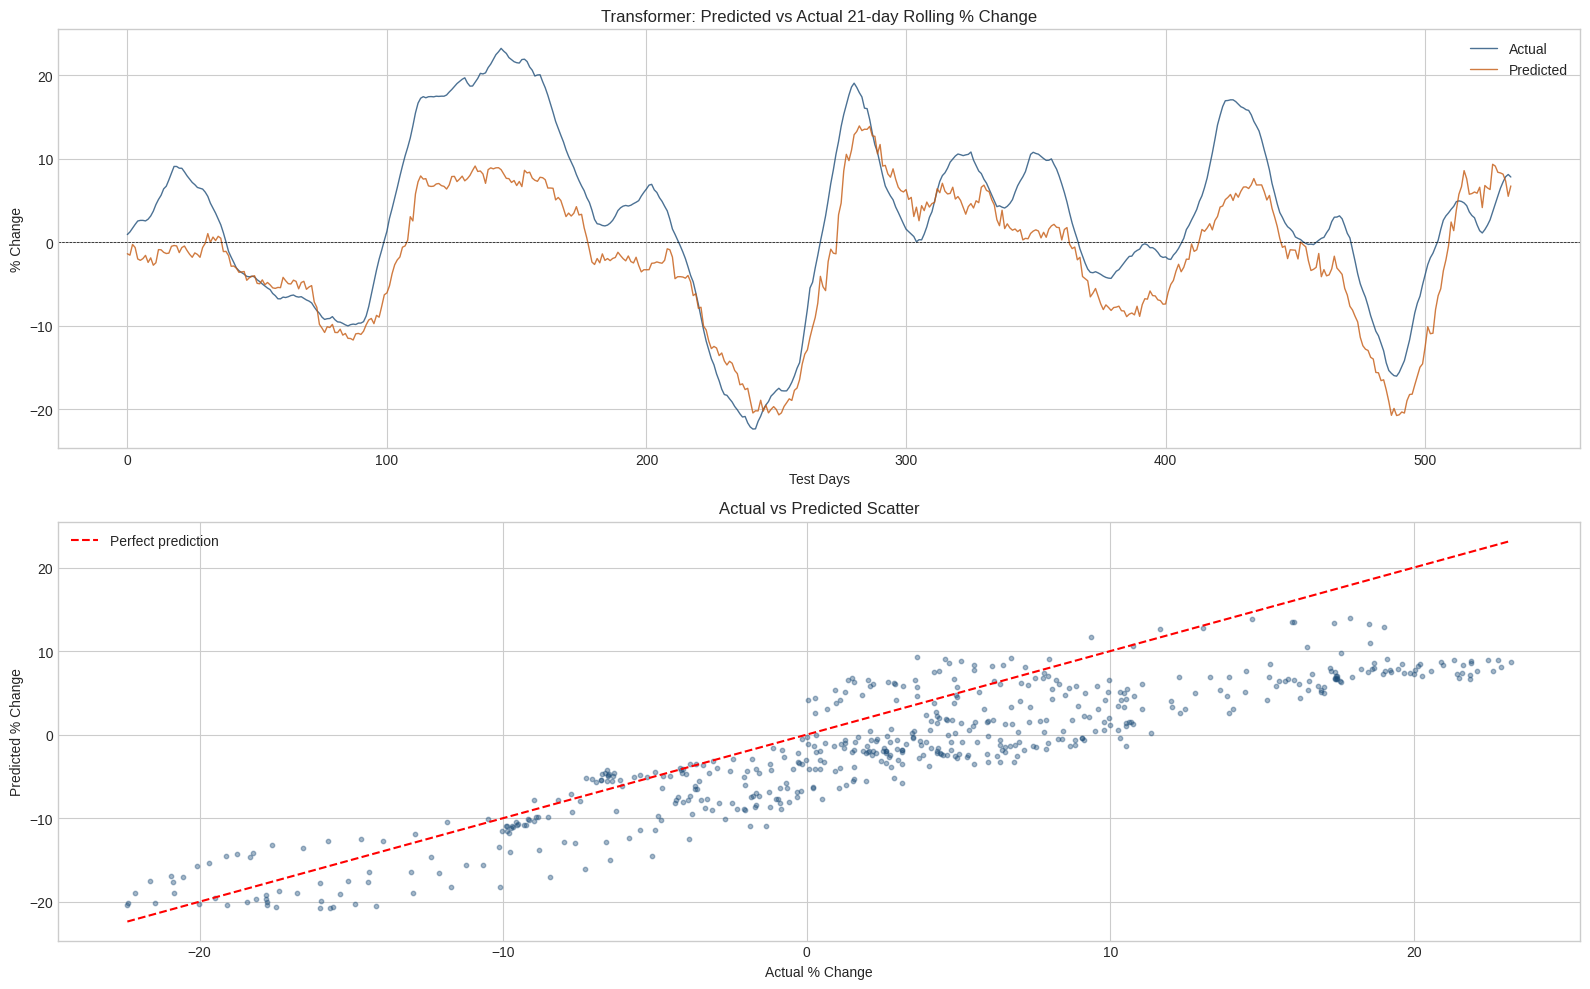

In [ ]:
# Evaluate Transformer Model

model_transformer.load_state_dict(
    torch.load('best_transformer_model.pth'))
model_transformer.eval()

preds_t   = []
actuals_t = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        output = model_transformer(X_batch)
        preds_t.extend(output.cpu().numpy())
        actuals_t.extend(y_batch.numpy())

preds_t   = scaler_y.inverse_transform(
    np.array(preds_t))
actuals_t = scaler_y.inverse_transform(
    np.array(actuals_t))

mae_t  = mean_absolute_error(actuals_t, preds_t)
rmse_t = np.sqrt(mean_squared_error(actuals_t, preds_t))
r2_t   = r2_score(actuals_t, preds_t)

print("=" * 50)
print("Transformer Results:")
print("=" * 50)
print(f"MAE:  {mae_t:.4f}%")
print(f"RMSE: {rmse_t:.4f}%")
print(f"R2:   {r2_t:.4f}")
print("=" * 50)

print("\nFinal Model Comparison:")
print(f"{'Metric':<10} {'LSTM v1':>10} {'LSTM Tuned':>12} {'Transformer':>13}")
print("-" * 48)
print(f"{'MAE':<10} {mae:>10.4f} {mae2:>12.4f} {mae_t:>13.4f}")
print(f"{'RMSE':<10} {rmse:>10.4f} {rmse2:>12.4f} {rmse_t:>13.4f}")
print(f"{'R2':<10} {r2:>10.4f} {r2_2:>12.4f} {r2_t:>13.4f}")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(actuals_t, color='#1f4e79',
             linewidth=1, label='Actual', alpha=0.8)
axes[0].plot(preds_t, color='#c55a11',
             linewidth=1, label='Predicted', alpha=0.8)
axes[0].axhline(0, color='black',
                linewidth=0.5, linestyle='--')
axes[0].set_title('Transformer: Predicted vs Actual '
                  '21-day Rolling % Change')
axes[0].set_xlabel('Test Days')
axes[0].set_ylabel('% Change')
axes[0].legend()

axes[1].scatter(actuals_t, preds_t,
                alpha=0.4, s=10, color='#1f4e79')
axes[1].plot([actuals_t.min(), actuals_t.max()],
             [actuals_t.min(), actuals_t.max()],
             'r--', linewidth=1.5,
             label='Perfect prediction')
axes[1].set_xlabel('Actual % Change')
axes[1].set_ylabel('Predicted % Change')
axes[1].set_title('Actual vs Predicted Scatter')
axes[1].legend()

plt.tight_layout()
plt.savefig('transformer_results.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Tuned Transformer — slightly larger model

model_transformer2 = TransformerModel(
    input_size=INPUT_SIZE,
    d_model=128,
    nhead=4,
    num_layers=4,
    dim_feedforward=512,
    dropout=0.1).to(device)

criterion_t2 = nn.MSELoss()
optimizer_t2 = torch.optim.AdamW(
    model_transformer2.parameters(),
    lr=0.0003, weight_decay=0.01)
scheduler_t2 = torch.optim.lr_scheduler\
    .ReduceLROnPlateau(optimizer_t2,
                       patience=10, factor=0.5)

best_val_t2        = float('inf')
patience_counter_t2 = 0
PATIENCE_T2        = 30
EPOCHS_T2          = 200

train_losses_t2 = []
val_losses_t2   = []

for epoch in range(EPOCHS_T2):
    model_transformer2.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer_t2.zero_grad()
        output = model_transformer2(X_batch)
        loss = criterion_t2(output, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model_transformer2.parameters(),
            max_norm=1.0)
        optimizer_t2.step()
        train_loss += loss.item()

    model_transformer2.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            output = model_transformer2(X_batch)
            loss = criterion_t2(output, y_batch)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss   /= len(test_loader)
    train_losses_t2.append(train_loss)
    val_losses_t2.append(val_loss)
    scheduler_t2.step(val_loss)

    if val_loss < best_val_t2:
        best_val_t2 = val_loss
        torch.save(model_transformer2.state_dict(),
                   'best_transformer2_model.pth')
        patience_counter_t2 = 0
    else:
        patience_counter_t2 += 1

    if patience_counter_t2 >= PATIENCE_T2:
        print(f"Early stopping at epoch {epoch+1}")
        break

    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS_T2} | "
              f"Train: {train_loss:.6f} | "
              f"Val: {val_loss:.6f}")

print(f"\nBest val loss: {best_val_t2:.6f}")
print(f"Total epochs: {len(train_losses_t2)}")

Epoch 20/200 | Train: 0.008346 | Val: 0.013067
Epoch 40/200 | Train: 0.004305 | Val: 0.006450
Epoch 60/200 | Train: 0.001577 | Val: 0.005859
Epoch 80/200 | Train: 0.001010 | Val: 0.002689
Epoch 100/200 | Train: 0.000816 | Val: 0.002850
Early stopping at epoch 117

Best val loss: 0.002206
Total epochs: 117


**Evaluate**

Final Model Comparison:
Metric        LSTM v1   LSTM Tuned   Trans v1  Trans Tuned
-------------------------------------------------------
MAE            7.2173       7.6425     5.2628       3.5809
RMSE           8.8346       9.3178     6.3685       4.3273
R2             0.2459       0.1612     0.6081       0.8191


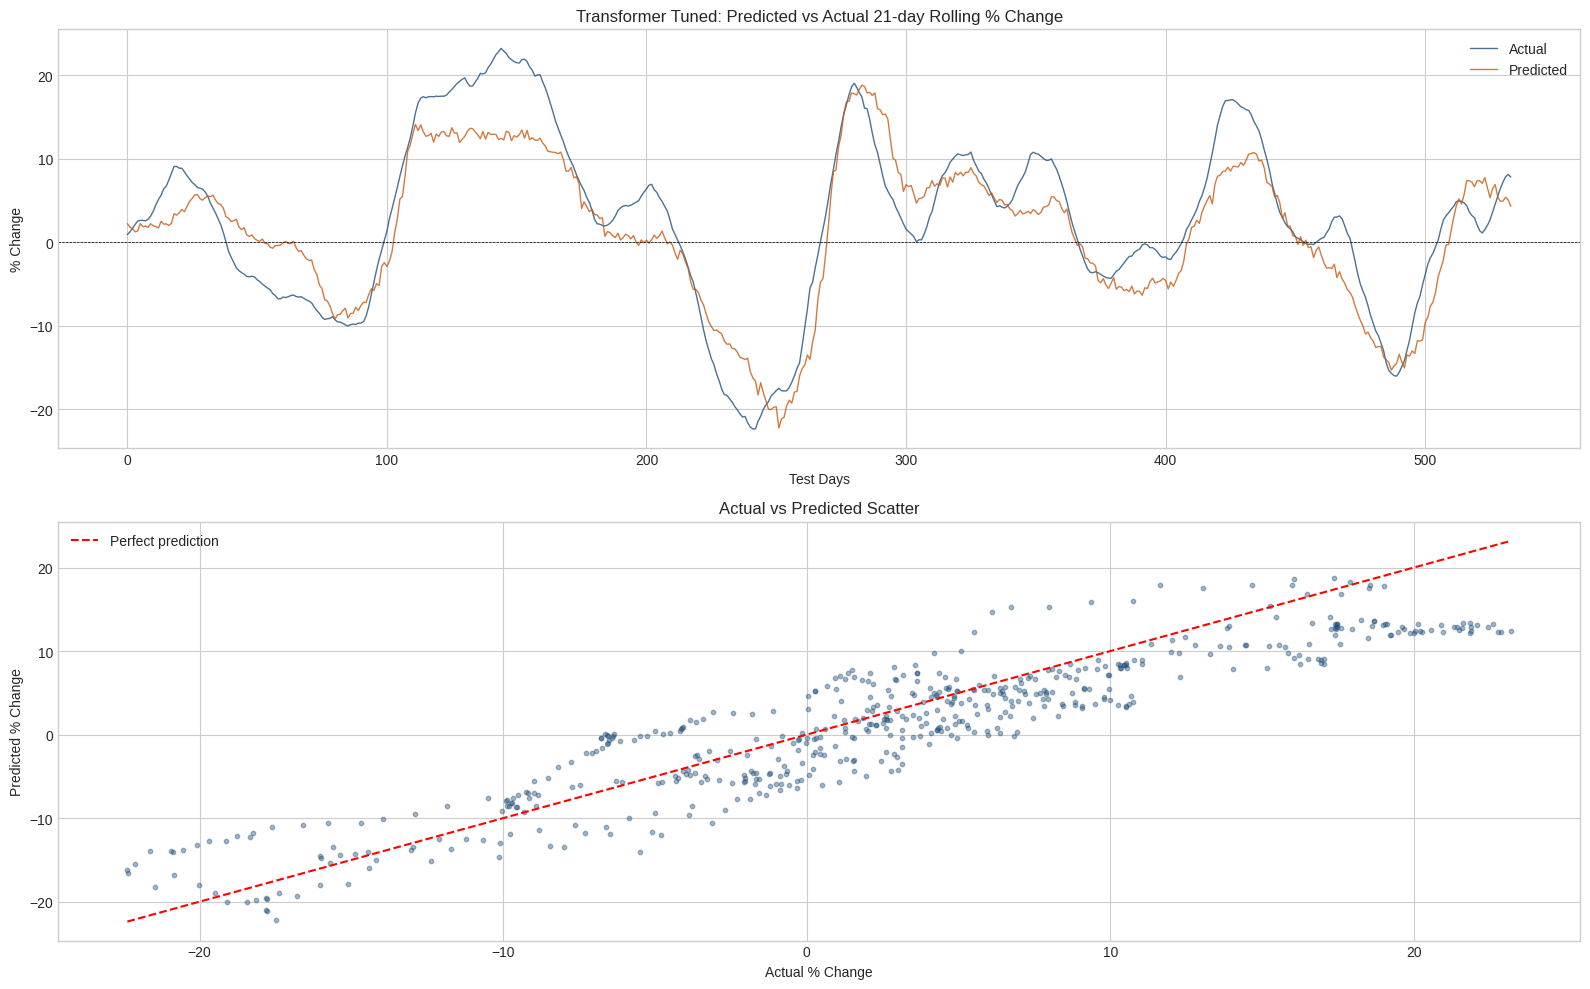

In [ ]:
# Evaluate Tuned Transformer Model

model_transformer2.load_state_dict(
    torch.load('best_transformer2_model.pth'))
model_transformer2.eval()

preds_t2   = []
actuals_t2 = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        output = model_transformer2(X_batch)
        preds_t2.extend(output.cpu().numpy())
        actuals_t2.extend(y_batch.numpy())

preds_t2   = scaler_y.inverse_transform(
    np.array(preds_t2))
actuals_t2 = scaler_y.inverse_transform(
    np.array(actuals_t2))

mae_t2  = mean_absolute_error(actuals_t2, preds_t2)
rmse_t2 = np.sqrt(mean_squared_error(actuals_t2, preds_t2))
r2_t2   = r2_score(actuals_t2, preds_t2)

print("=" * 55)
print("Final Model Comparison:")
print("=" * 55)
print(f"{'Metric':<10} {'LSTM v1':>10} {'LSTM Tuned':>12} "
      f"{'Trans v1':>10} {'Trans Tuned':>12}")
print("-" * 55)
print(f"{'MAE':<10} {mae:>10.4f} {mae2:>12.4f} "
      f"{mae_t:>10.4f} {mae_t2:>12.4f}")
print(f"{'RMSE':<10} {rmse:>10.4f} {rmse2:>12.4f} "
      f"{rmse_t:>10.4f} {rmse_t2:>12.4f}")
print(f"{'R2':<10} {r2:>10.4f} {r2_2:>12.4f} "
      f"{r2_t:>10.4f} {r2_t2:>12.4f}")
print("=" * 55)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(actuals_t2, color='#1f4e79',
             linewidth=1, label='Actual', alpha=0.8)
axes[0].plot(preds_t2, color='#c55a11',
             linewidth=1, label='Predicted', alpha=0.8)
axes[0].axhline(0, color='black',
                linewidth=0.5, linestyle='--')
axes[0].set_title('Transformer Tuned: Predicted vs Actual '
                  '21-day Rolling % Change')
axes[0].set_xlabel('Test Days')
axes[0].set_ylabel('% Change')
axes[0].legend()

axes[1].scatter(actuals_t2, preds_t2,
                alpha=0.4, s=10, color='#1f4e79')
axes[1].plot([actuals_t2.min(), actuals_t2.max()],
             [actuals_t2.min(), actuals_t2.max()],
             'r--', linewidth=1.5,
             label='Perfect prediction')
axes[1].set_xlabel('Actual % Change')
axes[1].set_ylabel('Predicted % Change')
axes[1].set_title('Actual vs Predicted Scatter')
axes[1].legend()

plt.tight_layout()
plt.savefig('transformer_tuned_results.png',
            dpi=150, bbox_inches='tight')
plt.show()

**Summary Table**

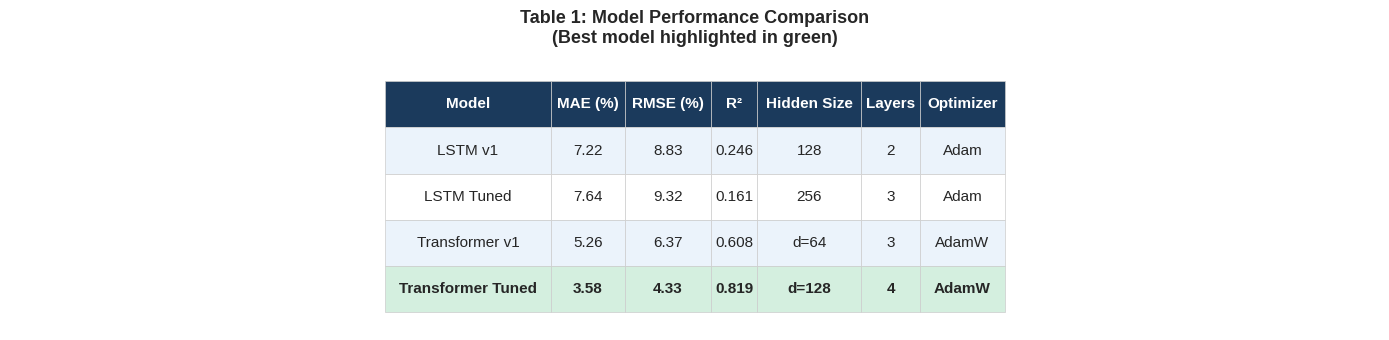

In [ ]:
# Clean  Results Table

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.axis('off')

columns = ['Model', 'MAE (%)', 'RMSE (%)', 'R²',
           'Hidden Size', 'Layers', 'Optimizer']

rows = [
    ['LSTM v1',           '7.22', '8.83', '0.246',
     '128', '2', 'Adam'],
    ['LSTM Tuned',        '7.64', '9.32', '0.161',
     '256', '3', 'Adam'],
    ['Transformer v1',    '5.26', '6.37', '0.608',
     'd=64', '3', 'AdamW'],
    ['Transformer Tuned', '3.58', '4.33', '0.819',
     'd=128', '4', 'AdamW'],
]

table = ax.table(
    cellText=rows,
    colLabels=columns,
    loc='center',
    cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.8)

# Set column widths
col_widths = [0.22, 0.10, 0.10, 0.10,
              0.13, 0.10, 0.12]
for j, width in enumerate(col_widths):
    table.auto_set_column_width(j)

# Header
for j in range(len(columns)):
    cell = table[0, j]
    cell.set_facecolor('#1B3A5C')
    cell.set_text_props(color='white',
                        fontweight='bold',
                        fontsize=11)

# Row colors
row_colors = ['#EBF3FB', '#FFFFFF',
              '#EBF3FB', '#D4EFDF']
for i, color in enumerate(row_colors, 1):
    for j in range(len(columns)):
        table[i, j].set_facecolor(color)

# Bold best model row
for j in range(len(columns)):
    table[4, j].set_text_props(
        fontweight='bold', fontsize=11)
    table[4, j].set_facecolor('#D4EFDF')

# Add border to all cells
for key, cell in table.get_celld().items():
    cell.set_edgecolor('#CCCCCC')
    cell.set_linewidth(0.5)

ax.set_title('Table 1: Model Performance Comparison\n'
             '(Best model highlighted in green)',
             fontsize=13, fontweight='bold',
             pad=15, loc='center')

plt.tight_layout()
plt.savefig('results_table_final.png',
            dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# Save all trained models to Google Drive

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

save_path = '/content/drive/MyDrive/EM10DS/models/'
import os
os.makedirs(save_path, exist_ok=True)

# Save all model weights
torch.save(model_lstm.state_dict(),
           save_path + 'lstm_v1.pth')
torch.save(model_lstm2.state_dict(),
           save_path + 'lstm_tuned.pth')
torch.save(model_transformer.state_dict(),
           save_path + 'transformer_v1.pth')
torch.save(model_transformer2.state_dict(),
           save_path + 'transformer_tuned.pth')

print("All models saved to Google Drive!")
print(f"Location: {save_path}")
print("Files saved:")
for f in os.listdir(save_path):
    print(f"   {f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All models saved to Google Drive!
Location: /content/drive/MyDrive/EM10DS/models/
Files saved:
   lstm_v1.pth
   lstm_tuned.pth
   transformer_v1.pth
   transformer_tuned.pth


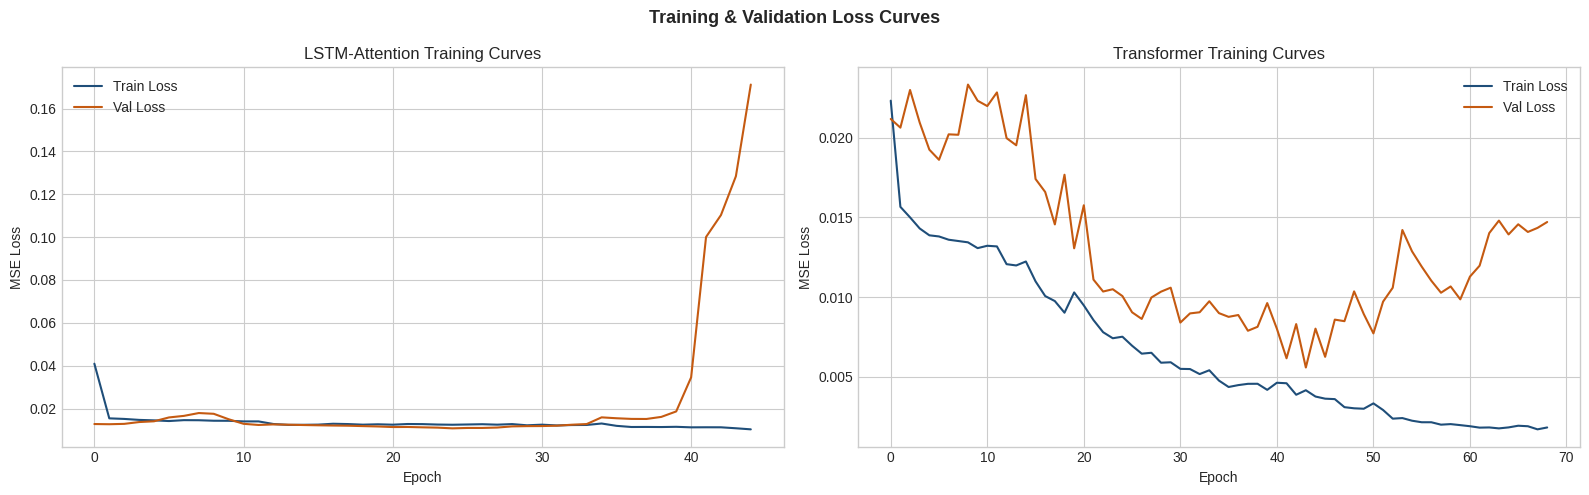

Training curves saved!


In [ ]:
# Training & Validation Loss Curves

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(train_losses, color='#1f4e79',
             linewidth=1.5, label='Train Loss')
axes[0].plot(val_losses, color='#c55a11',
             linewidth=1.5, label='Val Loss')
axes[0].set_title('LSTM-Attention Training Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].plot(train_losses_t, color='#1f4e79',
             linewidth=1.5, label='Train Loss')
axes[1].plot(val_losses_t, color='#c55a11',
             linewidth=1.5, label='Val Loss')
axes[1].set_title('Transformer Training Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()

plt.suptitle('Training & Validation Loss Curves',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(save_path + '../training_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved!")

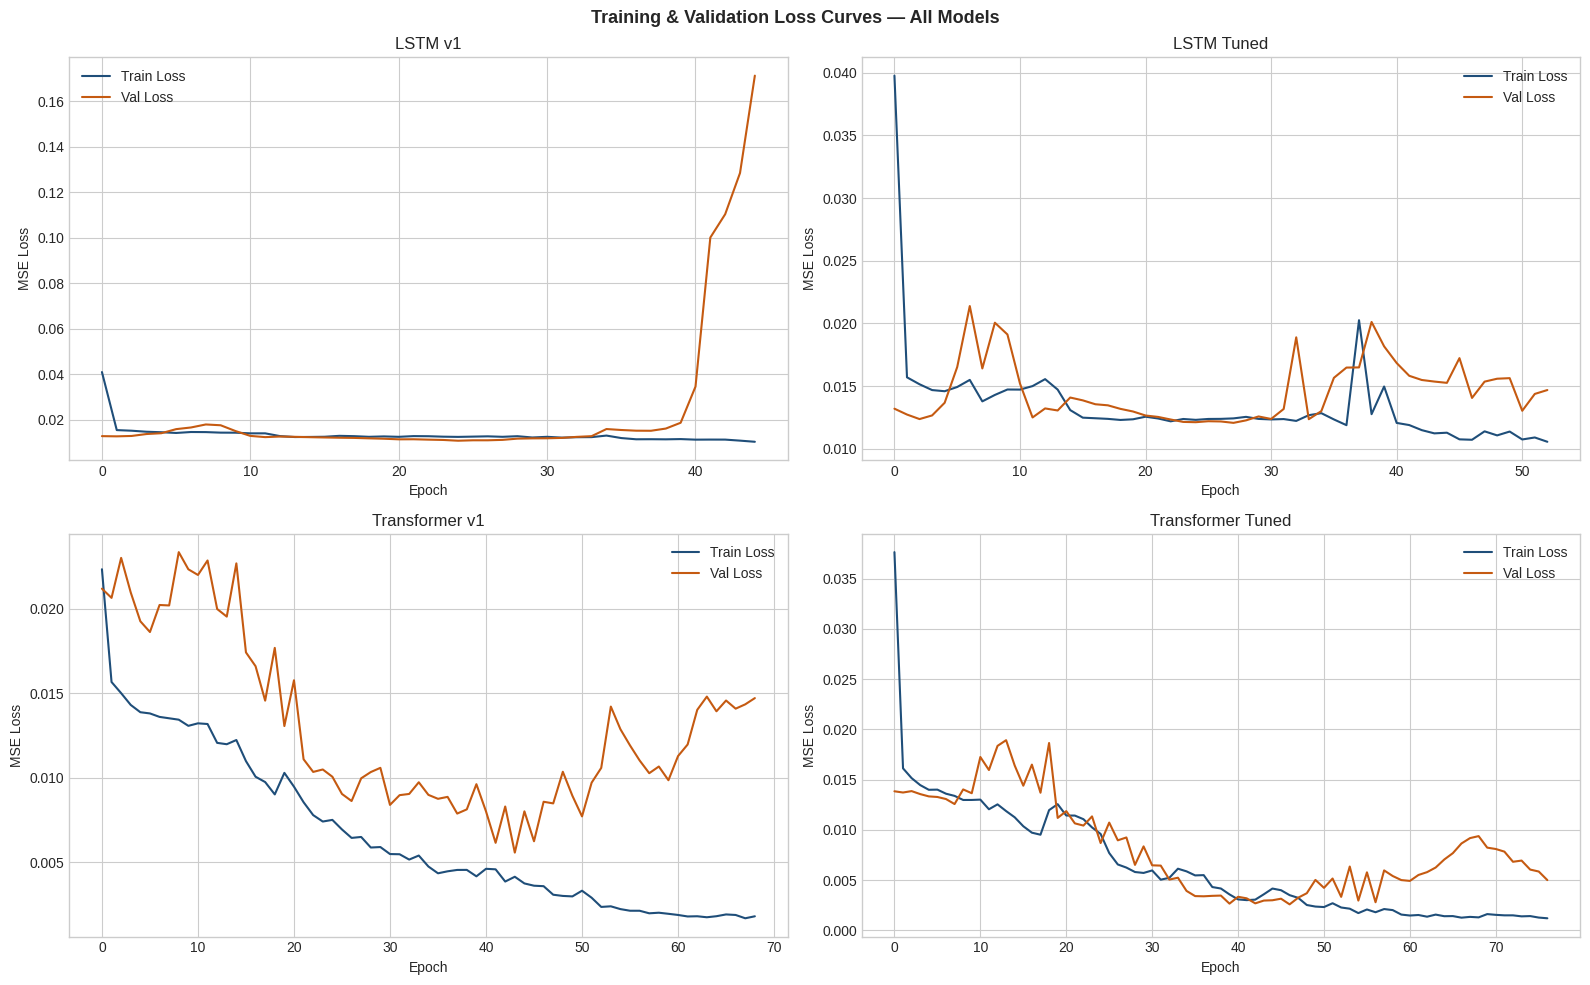

All training curves saved!


In [ ]:
# Training & Validation Loss Curves — All 4 Models

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# LSTM v1
axes[0][0].plot(train_losses, color='#1f4e79',
                linewidth=1.5, label='Train Loss')
axes[0][0].plot(val_losses, color='#c55a11',
                linewidth=1.5, label='Val Loss')
axes[0][0].set_title('LSTM v1')
axes[0][0].set_xlabel('Epoch')
axes[0][0].set_ylabel('MSE Loss')
axes[0][0].legend()

# LSTM Tuned
axes[0][1].plot(train_losses2, color='#1f4e79',
                linewidth=1.5, label='Train Loss')
axes[0][1].plot(val_losses2, color='#c55a11',
                linewidth=1.5, label='Val Loss')
axes[0][1].set_title('LSTM Tuned')
axes[0][1].set_xlabel('Epoch')
axes[0][1].set_ylabel('MSE Loss')
axes[0][1].legend()

# Transformer v1
axes[1][0].plot(train_losses_t, color='#1f4e79',
                linewidth=1.5, label='Train Loss')
axes[1][0].plot(val_losses_t, color='#c55a11',
                linewidth=1.5, label='Val Loss')
axes[1][0].set_title('Transformer v1')
axes[1][0].set_xlabel('Epoch')
axes[1][0].set_ylabel('MSE Loss')
axes[1][0].legend()

# Transformer Tuned
axes[1][1].plot(train_losses_t2, color='#1f4e79',
                linewidth=1.5, label='Train Loss')
axes[1][1].plot(val_losses_t2, color='#c55a11',
                linewidth=1.5, label='Val Loss')
axes[1][1].set_title('Transformer Tuned')
axes[1][1].set_xlabel('Epoch')
axes[1][1].set_ylabel('MSE Loss')
axes[1][1].legend()

plt.suptitle('Training & Validation Loss Curves — All Models',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(save_path + '../training_curves_all.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("All training curves saved!")

**SHAP Analysis**

Computing SHAP values...


  0%|          | 0/30 [00:00<?, ?it/s]

Done! Shape: (30, 11)


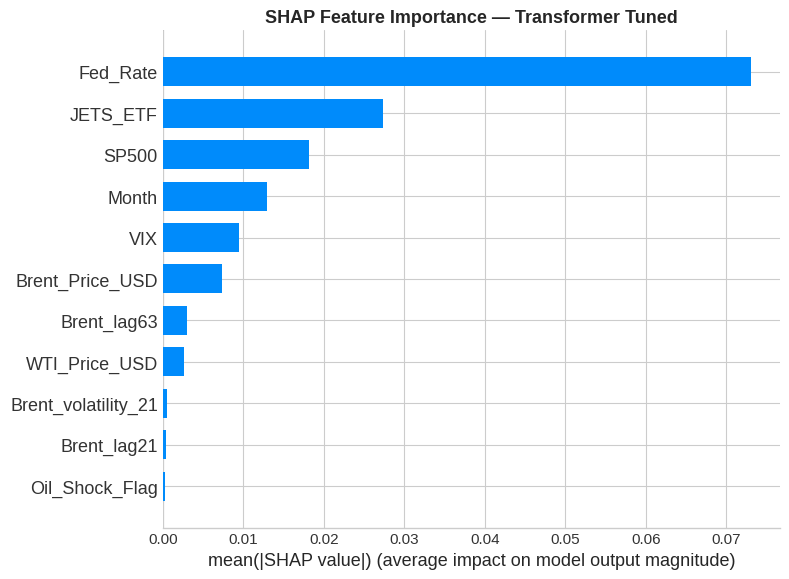

In [ ]:
# Fixed SHAP — use full sequence properly

model_transformer2.eval()

# Take 50 test samples as full sequences
X_shap_bg   = X_train_t[:50].cpu().numpy()
X_shap_test = X_test_t[:50].cpu().numpy()

# Flatten to 2D for SHAP (samples x features*timesteps)
# Then use mean across time dimension
X_bg_mean   = X_shap_bg.mean(axis=1)    # (50, 11)
X_test_mean = X_shap_test.mean(axis=1)  # (50, 11)

# Prediction wrapper using mean features
def predict_fn2(x):
    # Tile mean features across sequence
    x_seq = np.tile(
        x[:, np.newaxis, :],
        (1, SEQUENCE_LENGTH, 1))
    x_tensor = torch.FloatTensor(x_seq).to(device)
    with torch.no_grad():
        out = model_transformer2(x_tensor)
    return out.cpu().numpy().flatten()

# Compute SHAP
print("Computing SHAP values...")
explainer2   = shap.KernelExplainer(
    predict_fn2, X_bg_mean[:20])
shap_values2 = explainer2.shap_values(
    X_test_mean[:30], nsamples=100)
print(f"Done! Shape: {np.array(shap_values2).shape}")

# Bar plot
plt.figure(figsize=(12, 7))
shap.summary_plot(
    shap_values2,
    X_test_mean[:30],
    feature_names=feature_cols,
    plot_type='bar',
    show=False)
plt.title('SHAP Feature Importance — Transformer Tuned',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(save_path + '../shap_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()

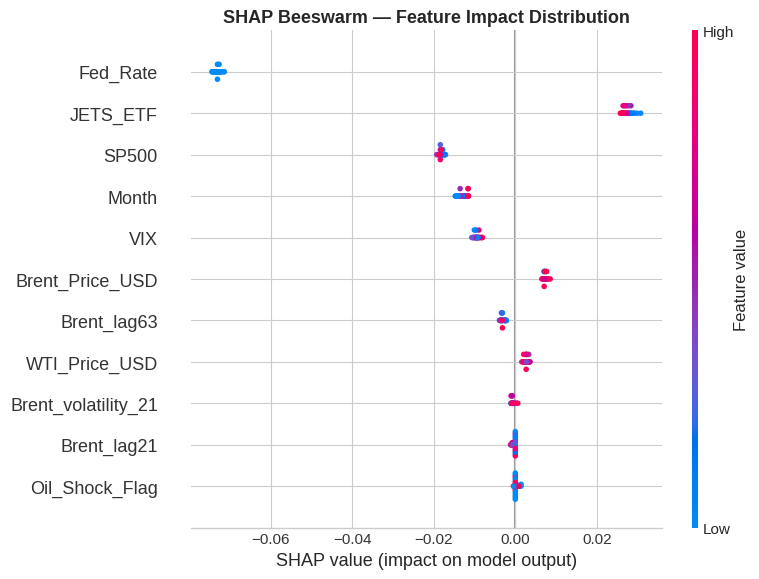

In [ ]:
# SHAP Beeswarm Plot
plt.figure(figsize=(12, 7))
shap.summary_plot(
    shap_values2,
    X_test_mean[:30],
    feature_names=feature_cols,
    show=False)
plt.title('SHAP Beeswarm — Feature Impact Distribution',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(save_path + '../shap_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()

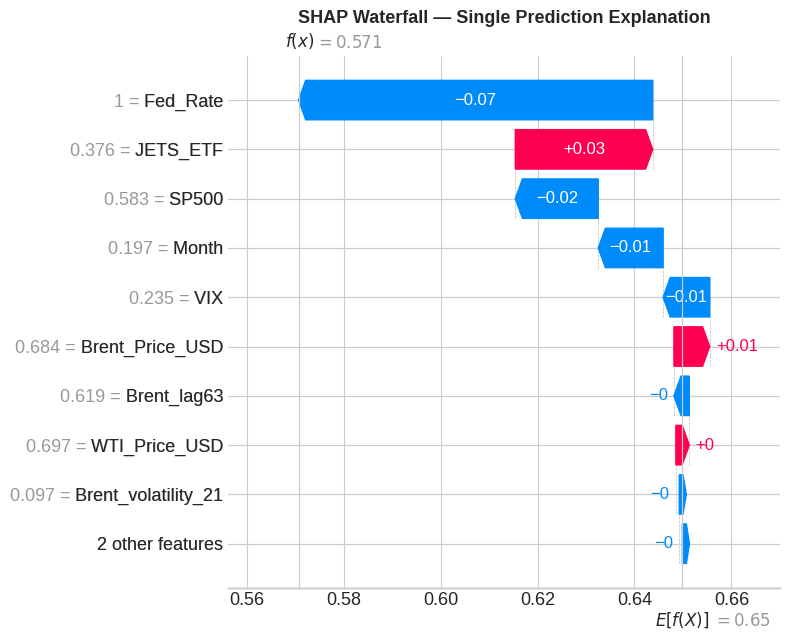

In [ ]:
# SHAP Waterfall Plot — single prediction explanation

shap_exp = shap.Explanation(
    values=shap_values2[10],
    base_values=explainer2.expected_value,
    data=X_test_mean[10],
    feature_names=feature_cols)

plt.figure(figsize=(12, 7))
shap.waterfall_plot(shap_exp, show=False)
plt.title('SHAP Waterfall — Single Prediction Explanation',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(save_path + '../shap_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()

Brent_Price_USD: R² drop = 0.0008
WTI_Price_USD: R² drop = 0.0036
Brent_lag21: R² drop = 0.0010
Brent_lag63: R² drop = 0.0003
Brent_volatility_21: R² drop = 0.0000
Oil_Shock_Flag: R² drop = -0.0036
VIX: R² drop = 0.0761
SP500: R² drop = -0.0026
Fed_Rate: R² drop = 0.0120
JETS_ETF: R² drop = 1.0239
Month: R² drop = 0.0202


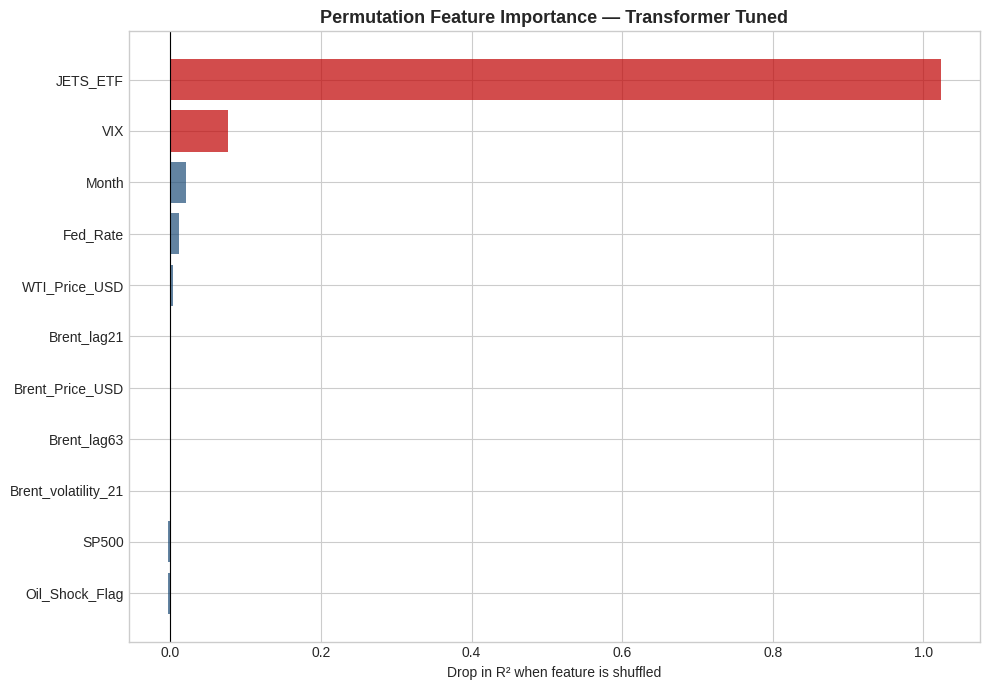


Top 5 most important features:
                R2_Drop
JETS_ETF       1.023889
VIX            0.076097
Month          0.020183
Fed_Rate       0.012011
WTI_Price_USD  0.003555


In [ ]:
# Permutation Feature Importance

model_transformer2.eval()
baseline_r2 = r2_t2

perm_importance = {}

for i, feat in enumerate(feature_cols):
    X_test_perm = X_test_t.clone()
    idx = torch.randperm(X_test_perm.shape[0])
    X_test_perm[:, :, i] = X_test_perm[idx, :, i]

    preds_perm = []
    with torch.no_grad():
        for j in range(0, len(X_test_perm), 32):
            batch = X_test_perm[j:j+32].to(device)
            out = model_transformer2(batch)
            preds_perm.extend(out.cpu().numpy())

    preds_perm = scaler_y.inverse_transform(
        np.array(preds_perm))
    r2_perm = r2_score(actuals_t2, preds_perm)
    perm_importance[feat] = baseline_r2 - r2_perm
    print(f"{feat}: R² drop = "
          f"{perm_importance[feat]:.4f}")

# Sort and plot
perm_df = pd.DataFrame.from_dict(
    perm_importance, orient='index',
    columns=['R2_Drop'])
perm_df = perm_df.sort_values(
    'R2_Drop', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#c00000' if x > 0.05
          else '#1f4e79'
          for x in perm_df['R2_Drop']]
ax.barh(perm_df.index, perm_df['R2_Drop'],
        color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Drop in R² when feature is shuffled')
ax.set_title('Permutation Feature Importance — '
             'Transformer Tuned',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(save_path + '../permutation_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
print(perm_df.sort_values(
    'R2_Drop', ascending=False).head())

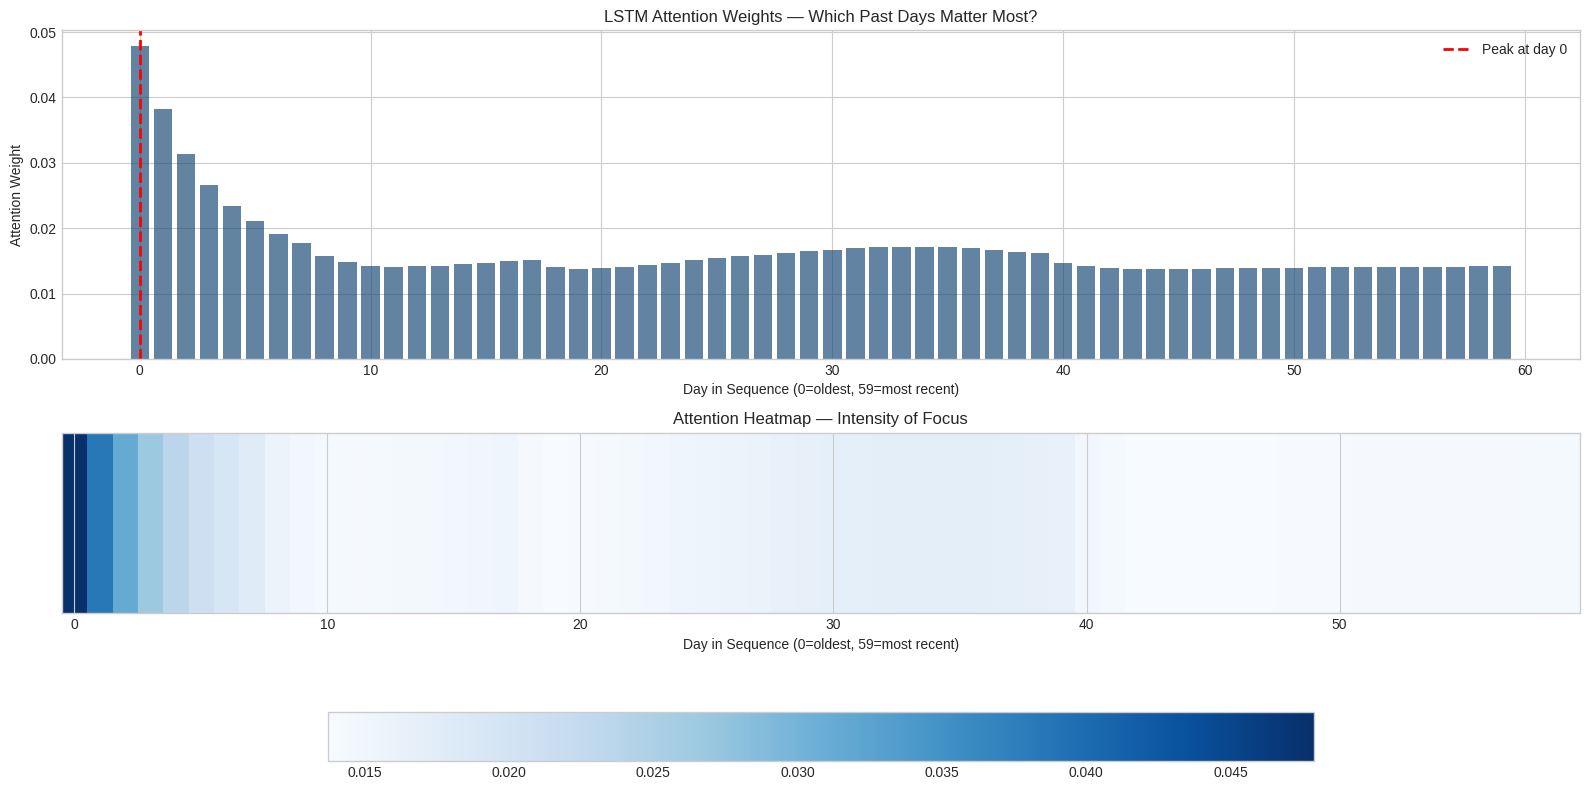

Peak attention at day: 0 (0=oldest, 59=most recent)
Peak weight value: 0.0479


In [ ]:
# Attention Weight Visualisation — LSTM Model
# Shows which past days the model focused on

model_lstm.eval()

# Pick test sample 50
sample_idx = 50
with torch.no_grad():
    sample = X_test_t[sample_idx:sample_idx+1]\
        .to(device)
    _, attn = model_lstm(sample)
    attn_weights = attn.squeeze().cpu().numpy()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Full sequence attention
axes[0].bar(range(len(attn_weights)),
            attn_weights,
            color='#1f4e79', alpha=0.7)
axes[0].set_xlabel(
    'Day in Sequence (0=oldest, 59=most recent)')
axes[0].set_ylabel('Attention Weight')
axes[0].set_title(
    'LSTM Attention Weights — '
    'Which Past Days Matter Most?')
axes[0].axvline(x=np.argmax(attn_weights),
                color='red', linewidth=2,
                linestyle='--',
                label=f'Peak at day '
                      f'{np.argmax(attn_weights)}')
axes[0].legend()

# Heatmap version
axes[1].imshow(
    attn_weights.reshape(1, -1),
    aspect='auto', cmap='Blues')
axes[1].set_xlabel(
    'Day in Sequence (0=oldest, 59=most recent)')
axes[1].set_title(
    'Attention Heatmap — Intensity of Focus')
axes[1].set_yticks([])
plt.colorbar(
    axes[1].images[0], ax=axes[1],
    orientation='horizontal', pad=0.3)

plt.tight_layout()
plt.savefig(save_path + '../attention_weights.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Peak attention at day: "
      f"{np.argmax(attn_weights)} "
      f"(0=oldest, 59=most recent)")
print(f"Peak weight value: "
      f"{attn_weights.max():.4f}")

In [ ]:
# Save results table to Drive
import shutil

shutil.copy('results_table_final.png',
            '/content/drive/MyDrive/EM10DS/'
            'results_table_final.png')

# Also save all prediction plots
for fname in ['lstm_results.png',
              'transformer_results.png',
              'transformer_tuned_results.png',
              'lstm_tuned_results.png']:
    try:
        shutil.copy(
            fname,
            f'/content/drive/MyDrive/EM10DS/{fname}')
        print(f"Saved: {fname}")
    except:
        print(f"Not found: {fname}")

print("\nAll files in Drive:")
for f in sorted(os.listdir(
        '/content/drive/MyDrive/EM10DS/')):
    print(f"   {f}")

Saved: lstm_results.png
Saved: transformer_results.png
Saved: transformer_tuned_results.png
Saved: lstm_tuned_results.png

All files in Drive:
   attention_weights.png
   cross_validation.png
   dataset_clean.csv
   lstm_results.png
   lstm_tuned_results.png
   models
   permutation_importance.png
   results_table_final.png
   shap_bar.png
   shap_beeswarm.png
   shap_waterfall.png
   training_curves.png
   training_curves_all.png
   transformer_results.png
   transformer_tuned_results.png
